In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cupy as cp
from cupyx.scipy.ndimage import gaussian_filter as gaussian_filter_gpu
from ezyrb import POD, Database, RegularGrid
from ezyrb import ReducedOrderModel as ROM
from smooth_POD_ROM.reduced_order_model import (
    train_ROM_rw,
    get_predictions_gpu,
    get_improvement,
    L2_error_rw,
)
from scipy.optimize import minimize, Bounds, direct

In [2]:
import matplotlib.pyplot as plt
import matplotlib as mpl
cmap = plt.colormaps.get_cmap("plasma")
single_column = 90  # mm
font_size_normal = 8

single_column_in = single_column/10/2.54
fw, fh = single_column_in, single_column_in/1.618
single_column_figure = (fw, fh)

plt.rcParams['font.size'] = font_size_normal
plt.rcParams["figure.figsize"] = single_column_figure

plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
plt.rcParams['legend.labelspacing'] = 0.25
plt.rcParams['legend.handlelength'] = 1.5
mpl.rc('text', usetex=True)
mpl.rc('font', family='serif', size=font_size_normal, serif='Computer Modern Roman')
pth = "../Plots/"

markevery = 40

In [3]:
pth = "C:/Users/florianma/OneDrive - Institutt for Energiteknikk/Documents/convolution_paper/data/Burger/"

X_val_all = np.load(pth + "X_val.npy").T
mu_val_all = np.load(pth + "mu_val.npy")[:, None]

shape = (257, 257)
x = y = np.linspace(0, 1, 257, endpoint=True)
dx = x[1] - x[0]
sigma, c = 0.003972, 0.9349  # 3.1*dx, 1

# Train: every 19th snapshot; layout (n_train, n_dof) for train_ROM_rw
X_train = X_val_all[::50]
mu_train = mu_val_all[::50, :]
print(mu_train.shape, X_train.shape, mu_train[[0, -1], :].ravel())

# Restrict validation to mu <= max(mu_train)
is_inside = mu_val_all[:, 0] <= mu_train[-1, 0]
mu_val = mu_val_all[is_inside]
X_val = X_val_all[is_inside]

# Test: 20 random snapshots (constant seed)
rng = np.random.default_rng(42)
n_test_want = 20
n_avail = len(mu_val)
inds = rng.choice(n_avail, size=min(n_test_want, n_avail), replace=False)
mu_test = mu_val_all[inds]
X_test = X_val_all[inds]

print(mu_test.shape, X_test.shape, mu_test[[0, -1], :].ravel())
print(X_train.shape, X_test.shape, X_val.shape)
print(mu_train.shape, mu_test.shape, mu_val.shape)

rank = len(mu_train)

(20, 1) (20, 66049) [0.   0.95]
(20, 1) (20, 66049) [0.722 0.495]
(20, 66049) (20, 66049) (951, 66049)
(20, 1) (20, 1) (951, 1)


In [4]:
n_test = X_test.shape[0]
case = {
    "sigma": 0.01145679 ,
    "c": 0.5,
    "num_iter": 50,
    "shape": shape,
    "x": x,
    "dx": dx,
    "mode": "reflect",
    "sigmaD": "calc_based_on_distance",
    "mu_train": mu_train,
    "mu_test": mu_test,
    "n_test": n_test,
    "rank": rank,
}


def target_function(case, X_e=X_test):
    sgm = case["sigma"] / case["dx"]
    mode = case["mode"]
    mu__ = case["mu"]
    print(len(mu_train), len(mu__), case["sigma"], case["c"], case["sigmaD"][0], case["num_iter"], end=" ")
    # GPU smoothing of training set (stack -> gaussian_filter_gpu -> mass conservation -> flatten)
    X_train_gpu = cp.asarray(X_train.reshape(-1, *shape).astype(np.float32))
    m0 = cp.sum(X_train_gpu, axis=(1, 2), keepdims=True)
    out = gaussian_filter_gpu(X_train_gpu, sigma=(0, sgm, sgm), truncate=8, mode=mode)
    m1 = cp.sum(out, axis=(1, 2), keepdims=True)
    out = out * cp.where(m1 > 0, m0 / m1, 1.0)
    X_train_s = cp.asnumpy(out).reshape(len(X_train), -1)
    #print(mu_train.shape, X_train.shape, X_train.shape)
    my_ROM = train_ROM_rw(mu_train, X_train)
    my_sROM = train_ROM_rw(mu_train, X_train_s)
    X___ROM = my_ROM.predict(mu__).snapshots_matrix
    X___sROM, X___sROMs = get_predictions_gpu(my_sROM, mu__, **case)

    mu__ = case["mu"]
    mean_ROM, mean_sROM, mean_sROMs, improvement = get_improvement(
        X_e, X___ROM, X___sROM, X___sROMs, norm=L2_error_rw, scaler=False
    )
    print(mean_ROM, mean_sROM, mean_sROMs, improvement)
    return mean_ROM, mean_sROM, mean_sROMs, X___ROM, X___sROM, X___sROMs

In [5]:
case["mu"] = mu_test
mean_ROM, mean_sROM, mean_sROMs, X_test_ROM, X_test_sROM, X_test_sROMs = target_function(case, X_e=X_test)
e_ROM = L2_error_rw(X_test_ROM, X_test)
e_sROM = L2_error_rw(X_test_sROM, X_test)
e_sROMs = L2_error_rw(X_test_sROMs, X_test)
print(e_ROM)
print(e_sROM)
print(e_sROMs)
print(e_sROMs/e_ROM)

20 20 0.01145679 0.5 c 50 0.013959578413924357 0.018770766076320035 0.010027683876076488 -28.166284262036854
[0.01115374 0.01252578 0.0216944  0.00668654 0.00201383 0.01068559
 0.03027342 0.0288259  0.010105   0.01724088 0.00954682 0.03053832
 0.02421258 0.0024999  0.0238234  0.00496462 0.00436795 0.01690809
 0.00368318 0.00744163]
[0.01419743 0.01516152 0.02555089 0.01102799 0.01144692 0.01412399
 0.028791   0.02891752 0.01564465 0.019993   0.02012971 0.02959044
 0.02333108 0.01141626 0.02727386 0.01338736 0.01256529 0.02150689
 0.01371269 0.01764683]
[0.0081618  0.00780814 0.01086246 0.00595695 0.00295582 0.00800304
 0.02193054 0.01648694 0.01014283 0.00870318 0.01261881 0.01848381
 0.01508094 0.00485891 0.01250804 0.00354398 0.00322771 0.0167006
 0.00690993 0.00560926]
[0.73175464 0.62336531 0.50070334 0.8908863  1.46776372 0.74895581
 0.72441575 0.57194898 1.00374332 0.50479908 1.32178183 0.60526616
 0.62285557 1.94364048 0.52503164 0.71384788 0.73895174 0.98772807
 1.87607444 0.75

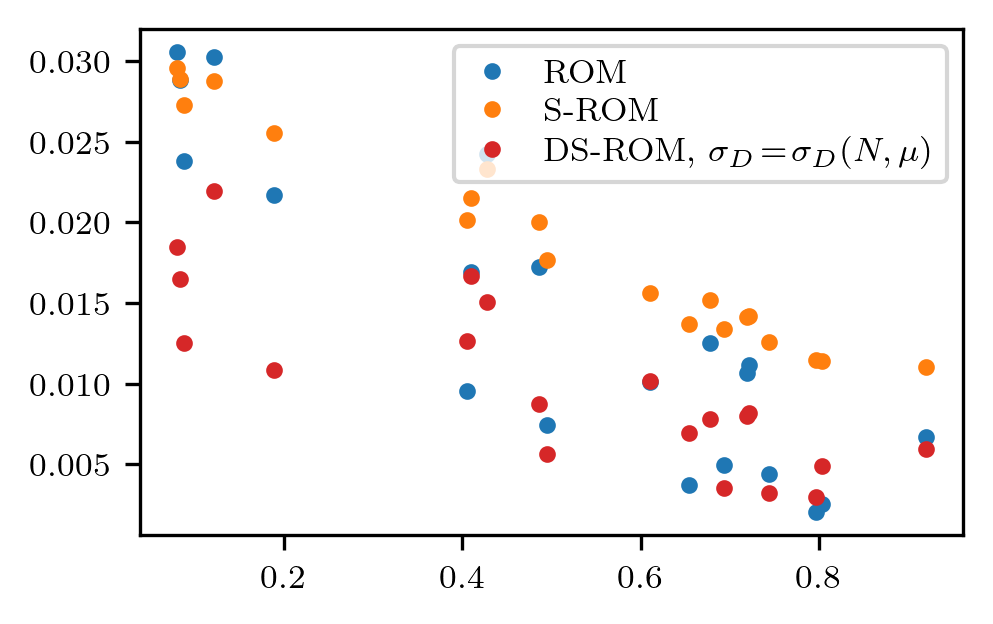

In [6]:
fig, ax = plt.subplots()
ax.plot(mu_test.ravel(), e_ROM, "C0o", ms=3, label=r"ROM")
ax.plot(mu_test.ravel(), e_sROM, "C1o", ms=3, label=r"S-ROM")
ax.plot(mu_test.ravel(), e_sROMs, "C3o", ms=3, label=r"DS-ROM, $\sigma_D\!=\!\sigma_D(N, \mu)$")  #  (\sigma_S, c)
plt.legend()
plt.show()

0 [0.722] 0.01115373848730243 0.014197428476756146 0.008161799875805112 -26.82453614008776


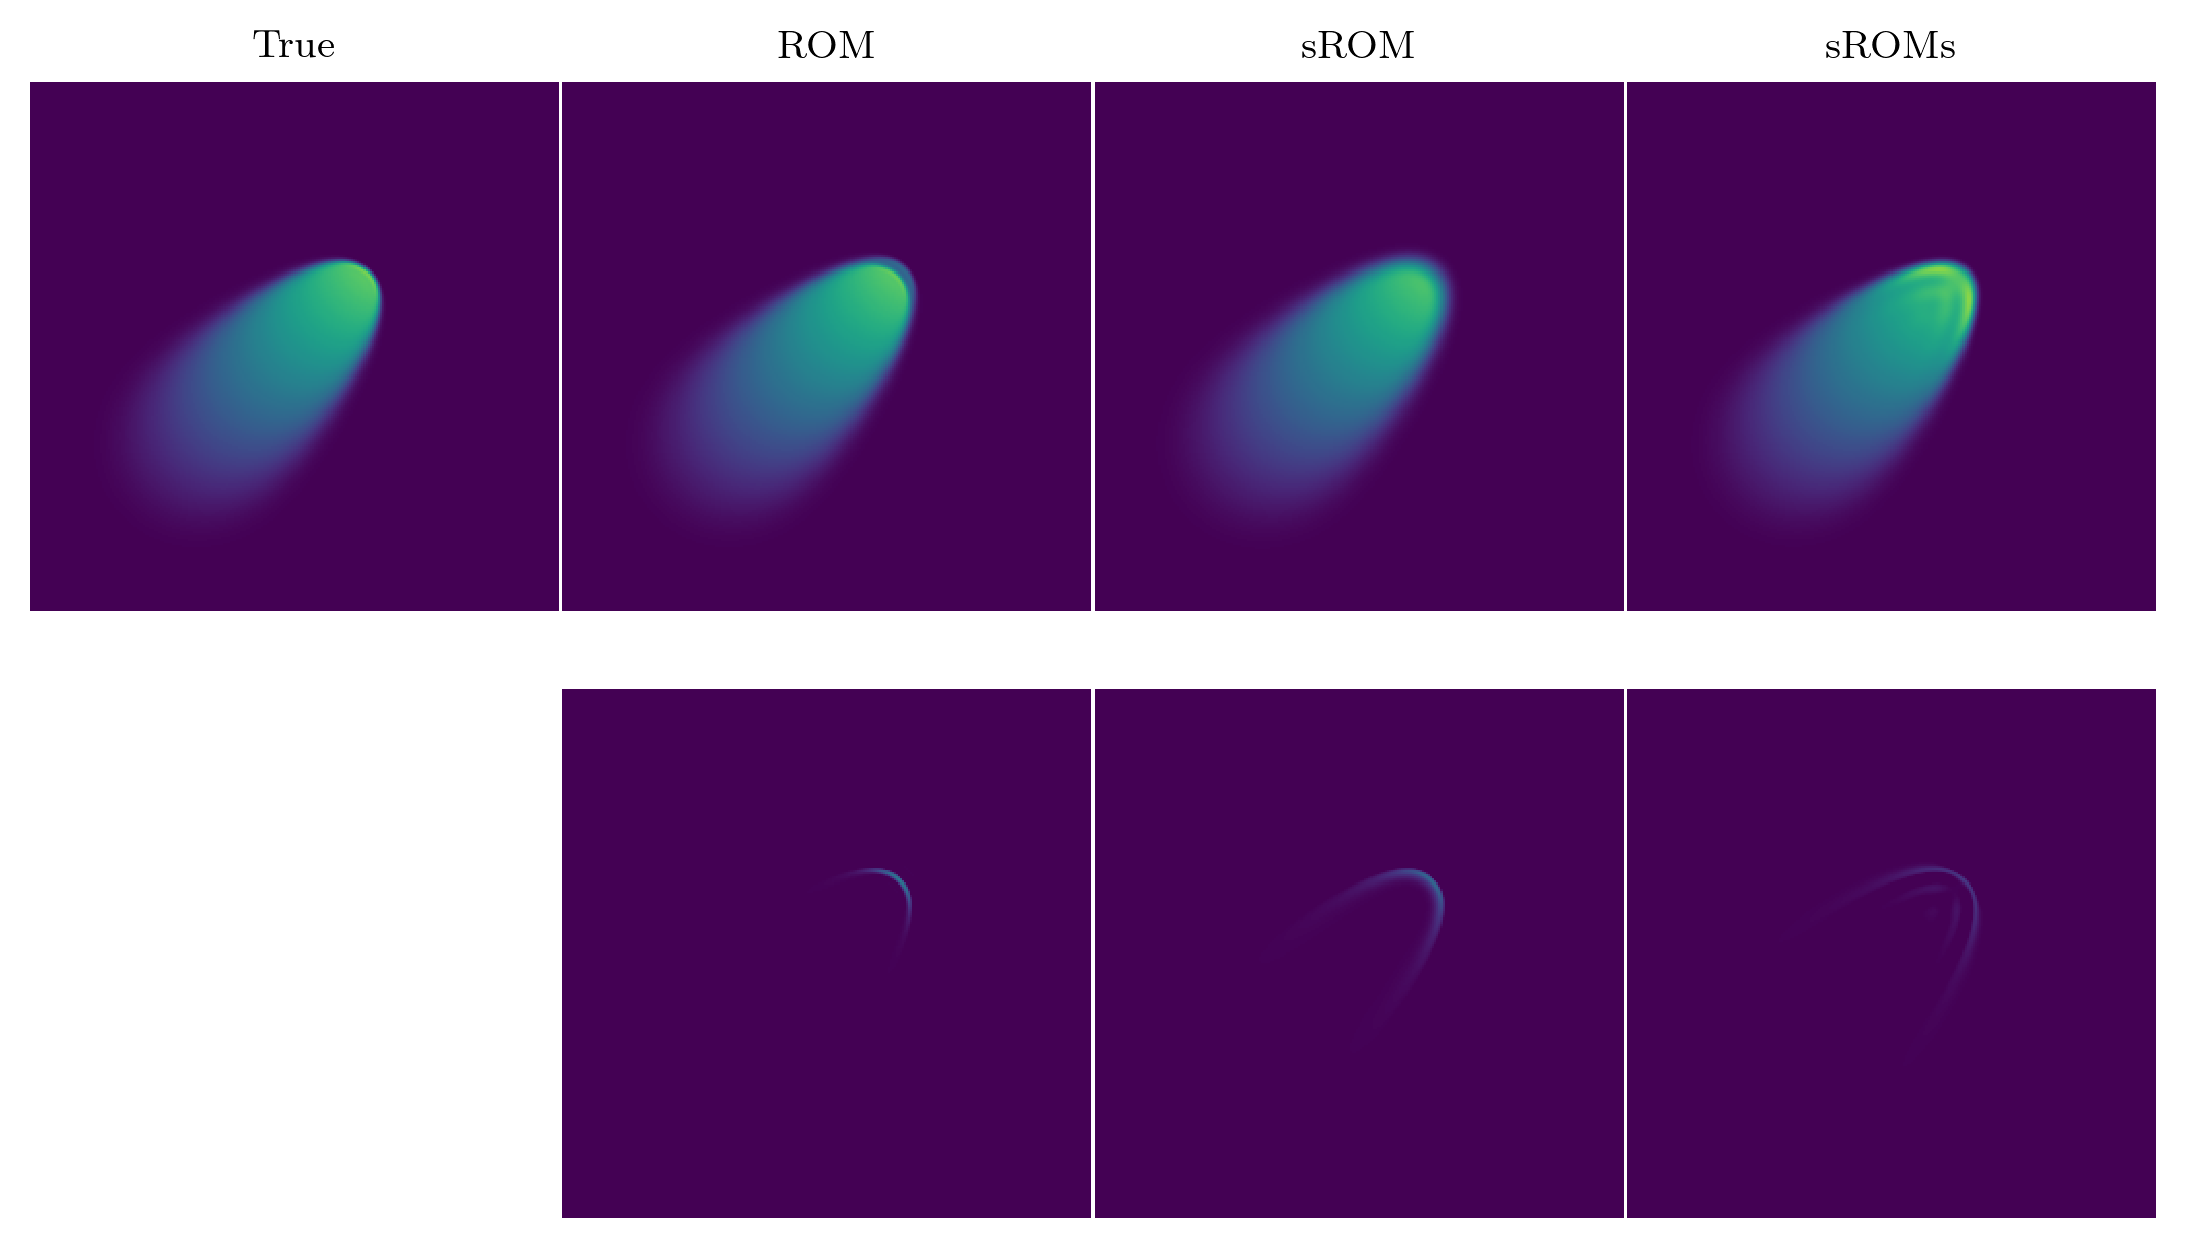

1 [0.678] 0.012525779116692254 0.015161521860471169 0.0078081361367654395 -37.66346936167773


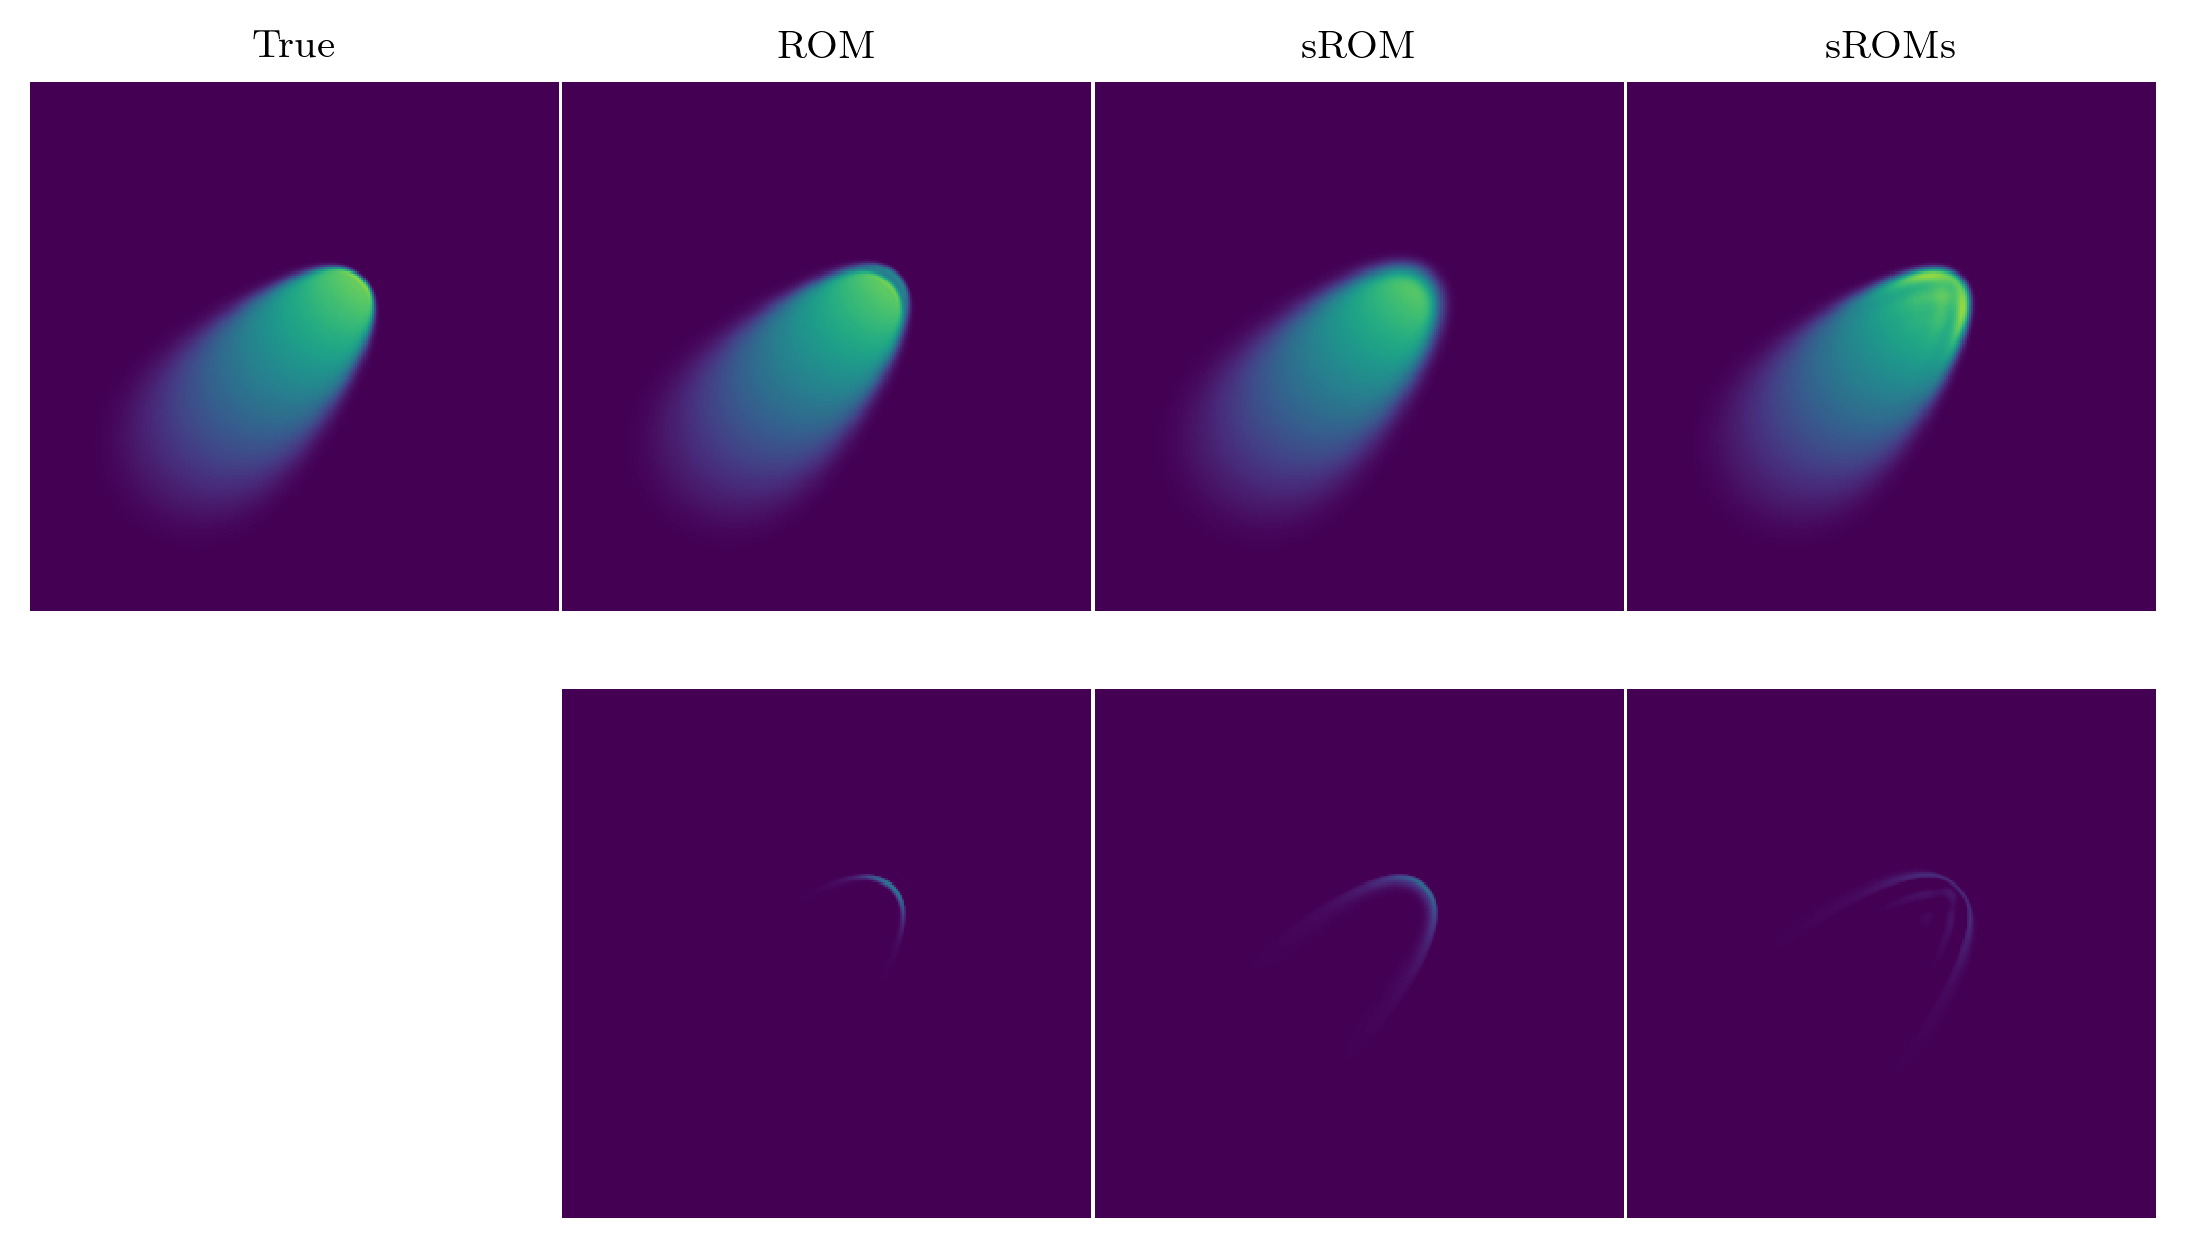

2 [0.189] 0.02169439811993012 0.02555089417709808 0.010862457606557014 -49.92966596027416


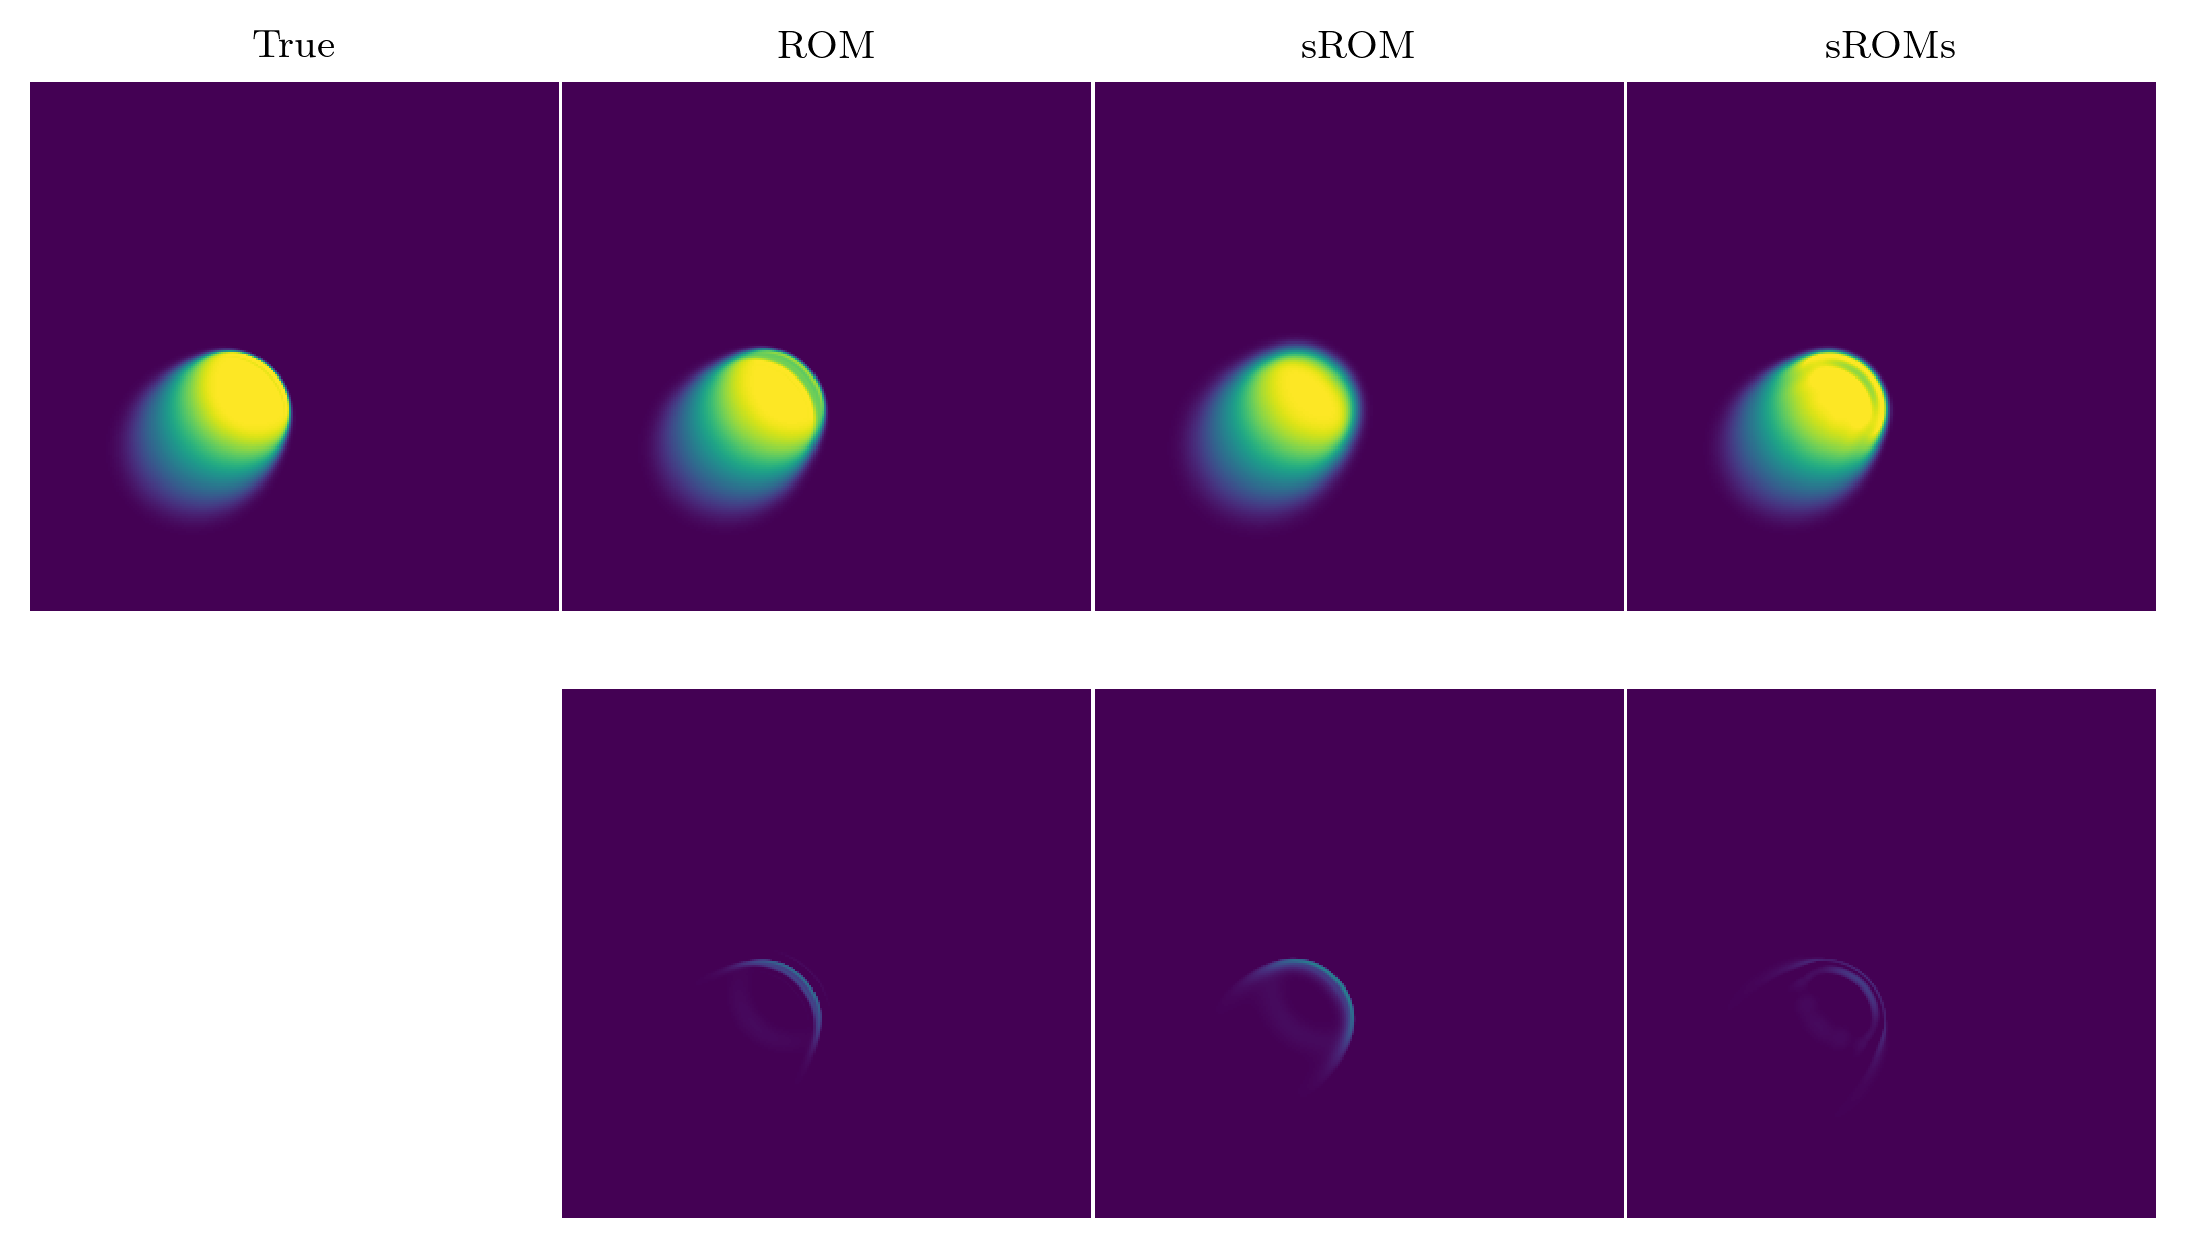

3 [0.92] 0.006686541191542352 0.011027989616876014 0.005956947952797406 -10.91136983748477


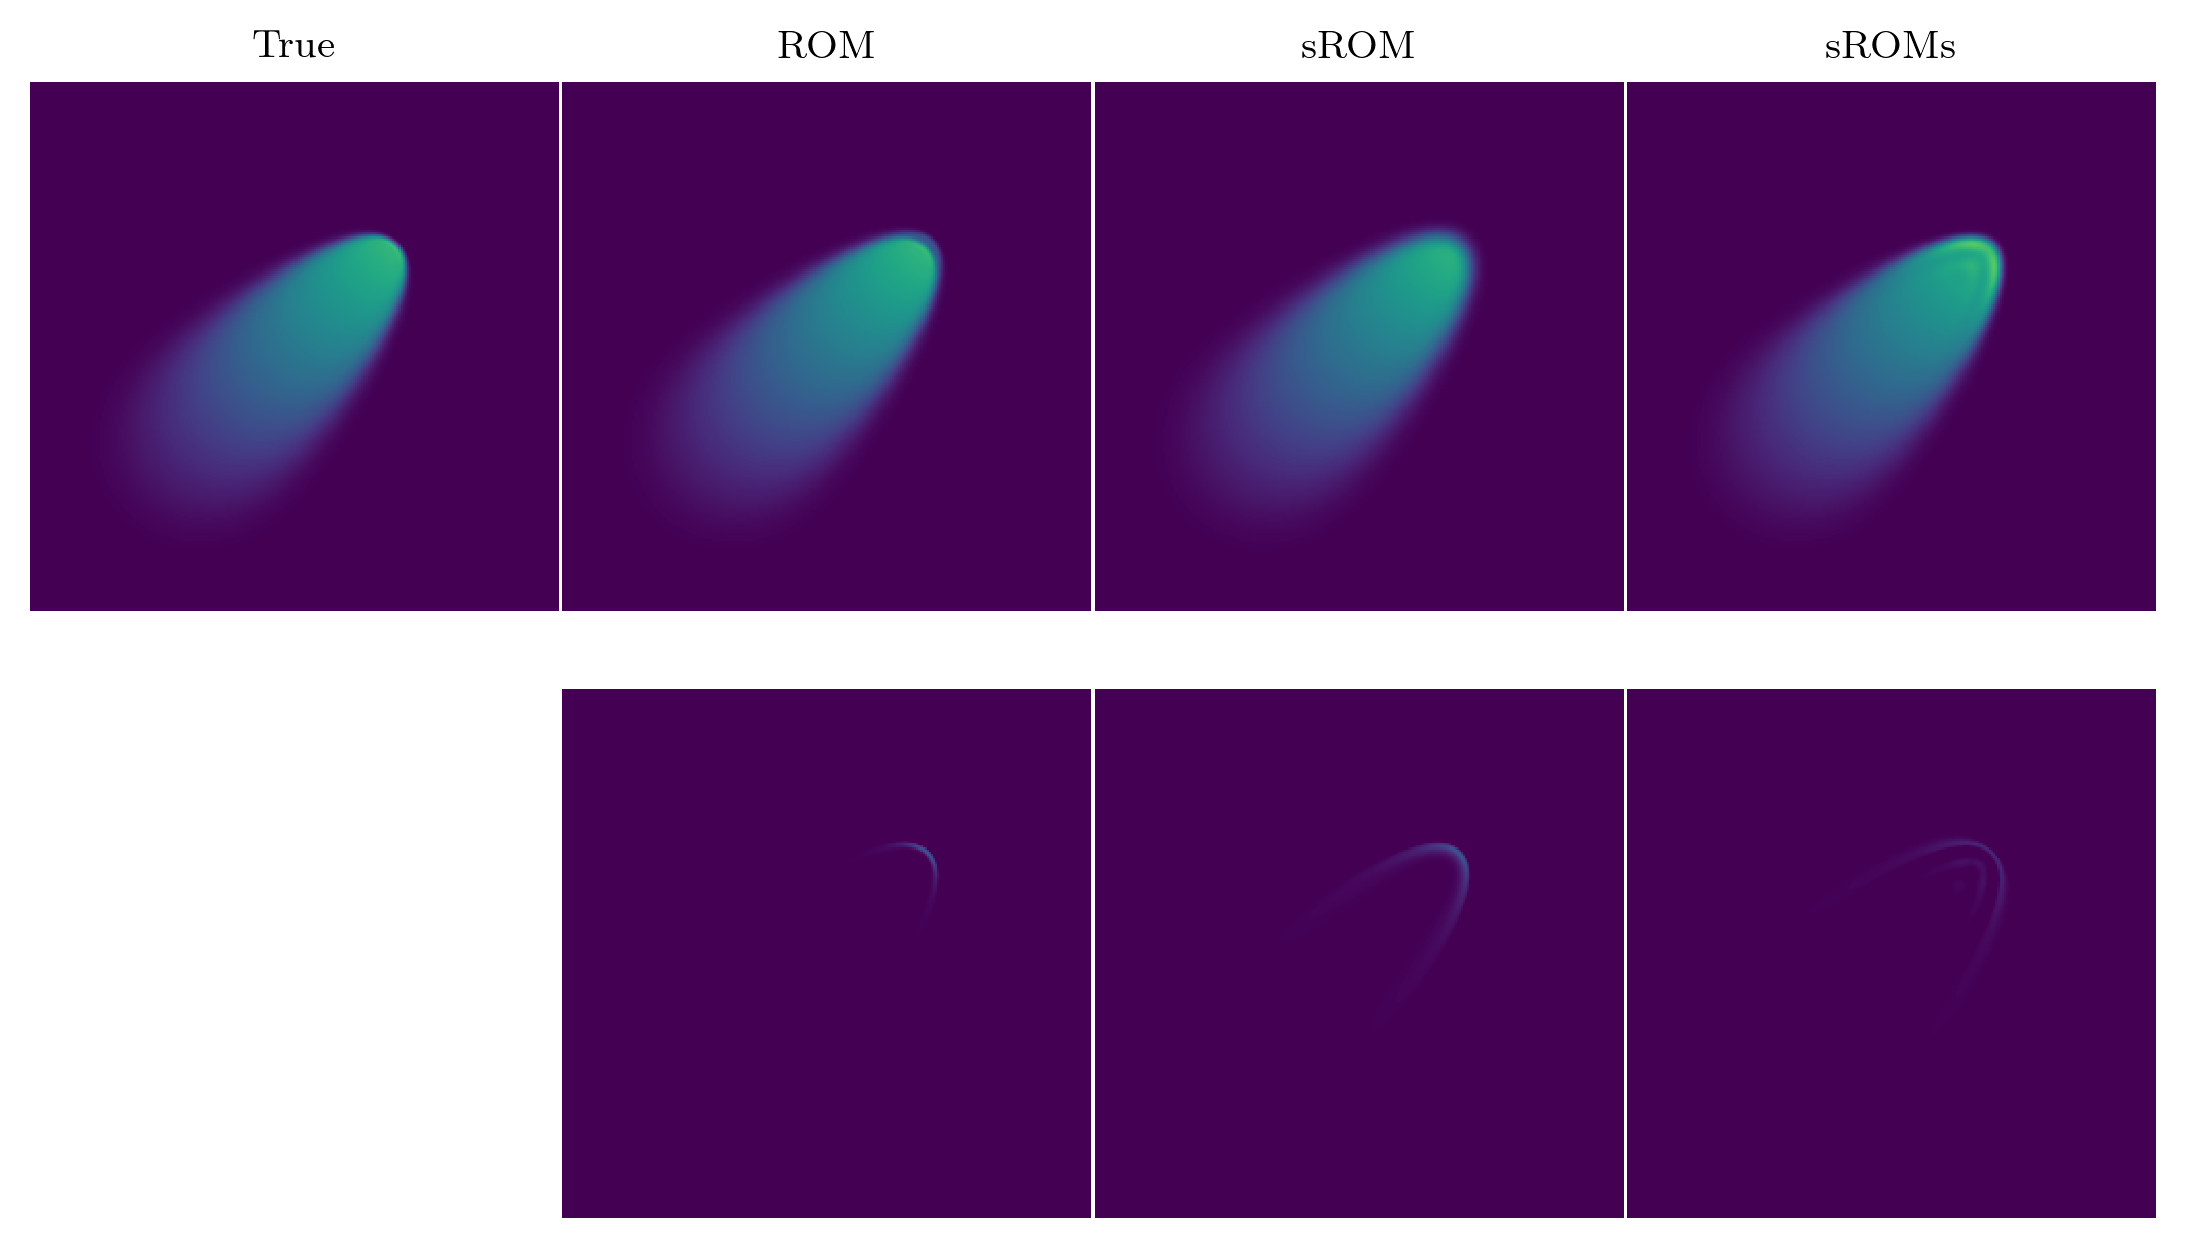

4 [0.797] 0.0020138260462950284 0.01144692131975568 0.0029558208150201677 46.776372291846684


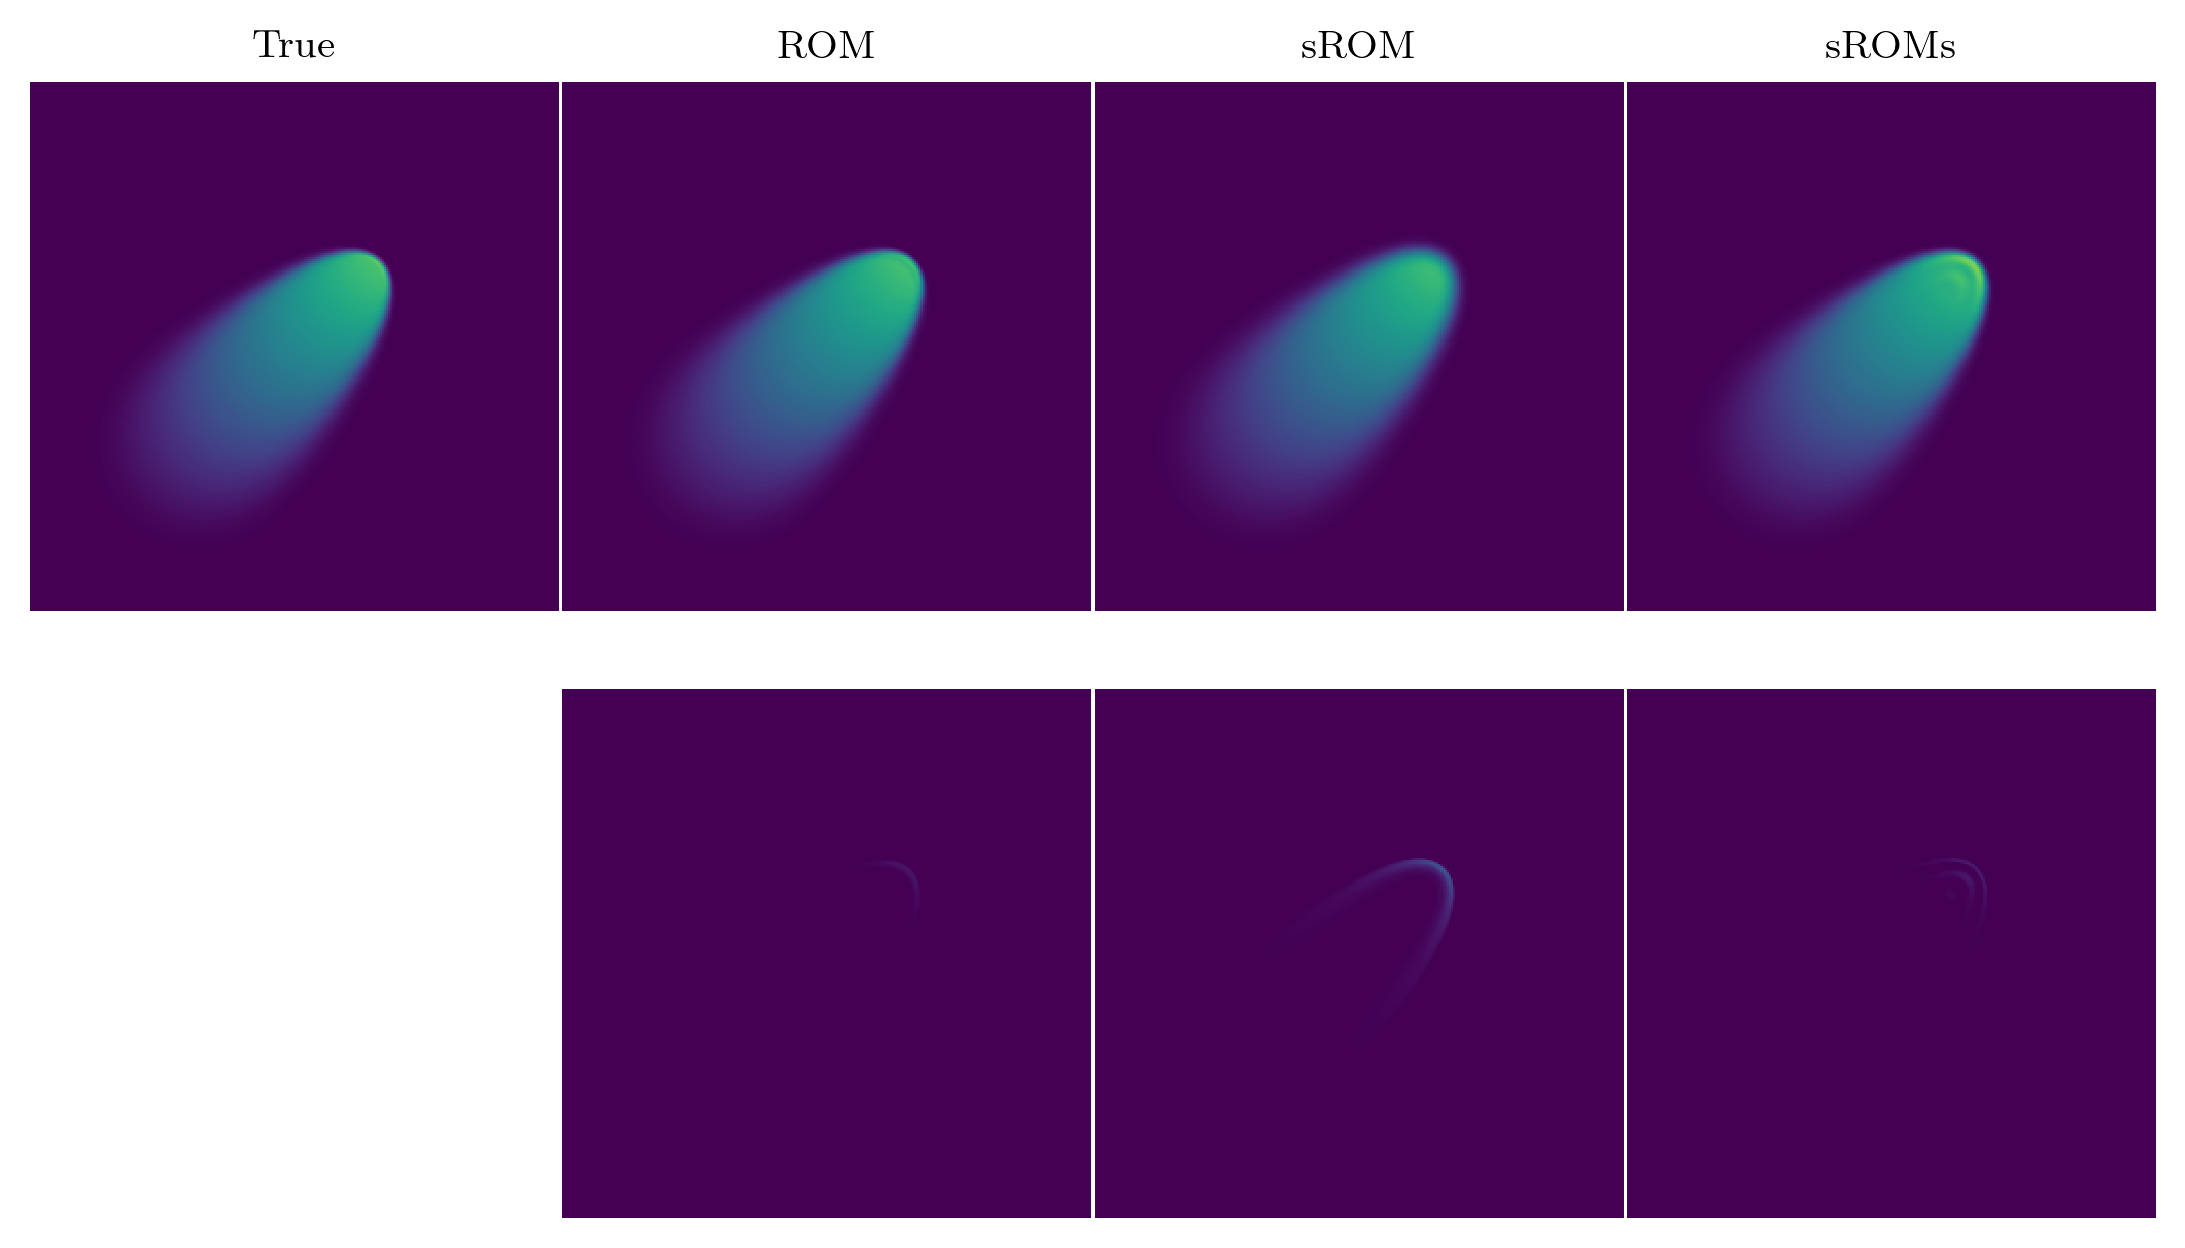

5 [0.719] 0.01068559329213154 0.014123987418007848 0.008003037220692576 -25.104418613932225


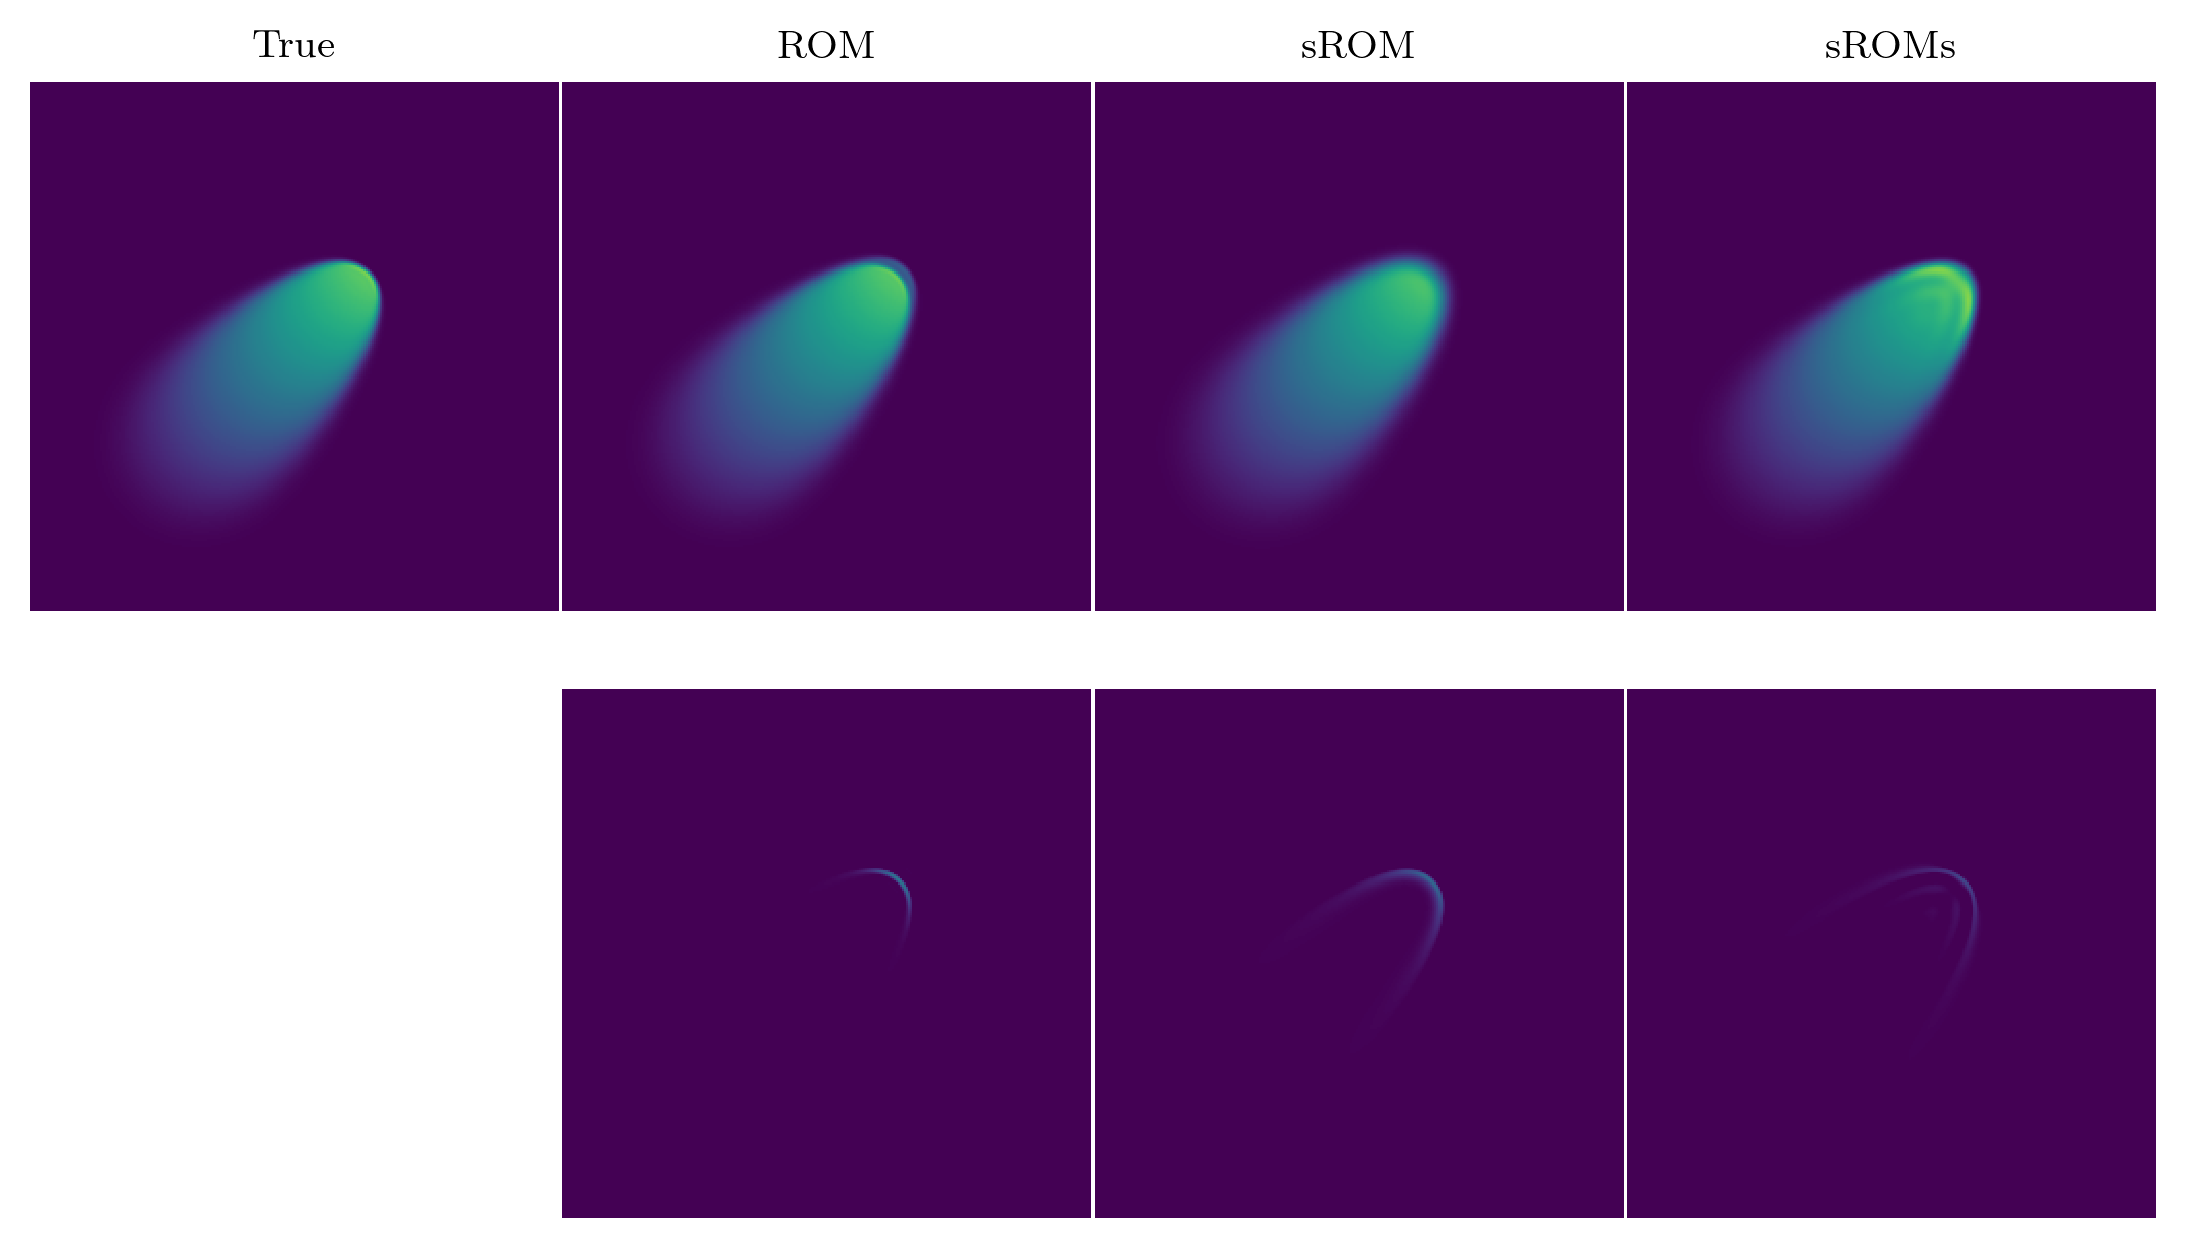

6 [0.121] 0.030273419756417966 0.028790998064969306 0.021930541965365733 -27.558425371760464


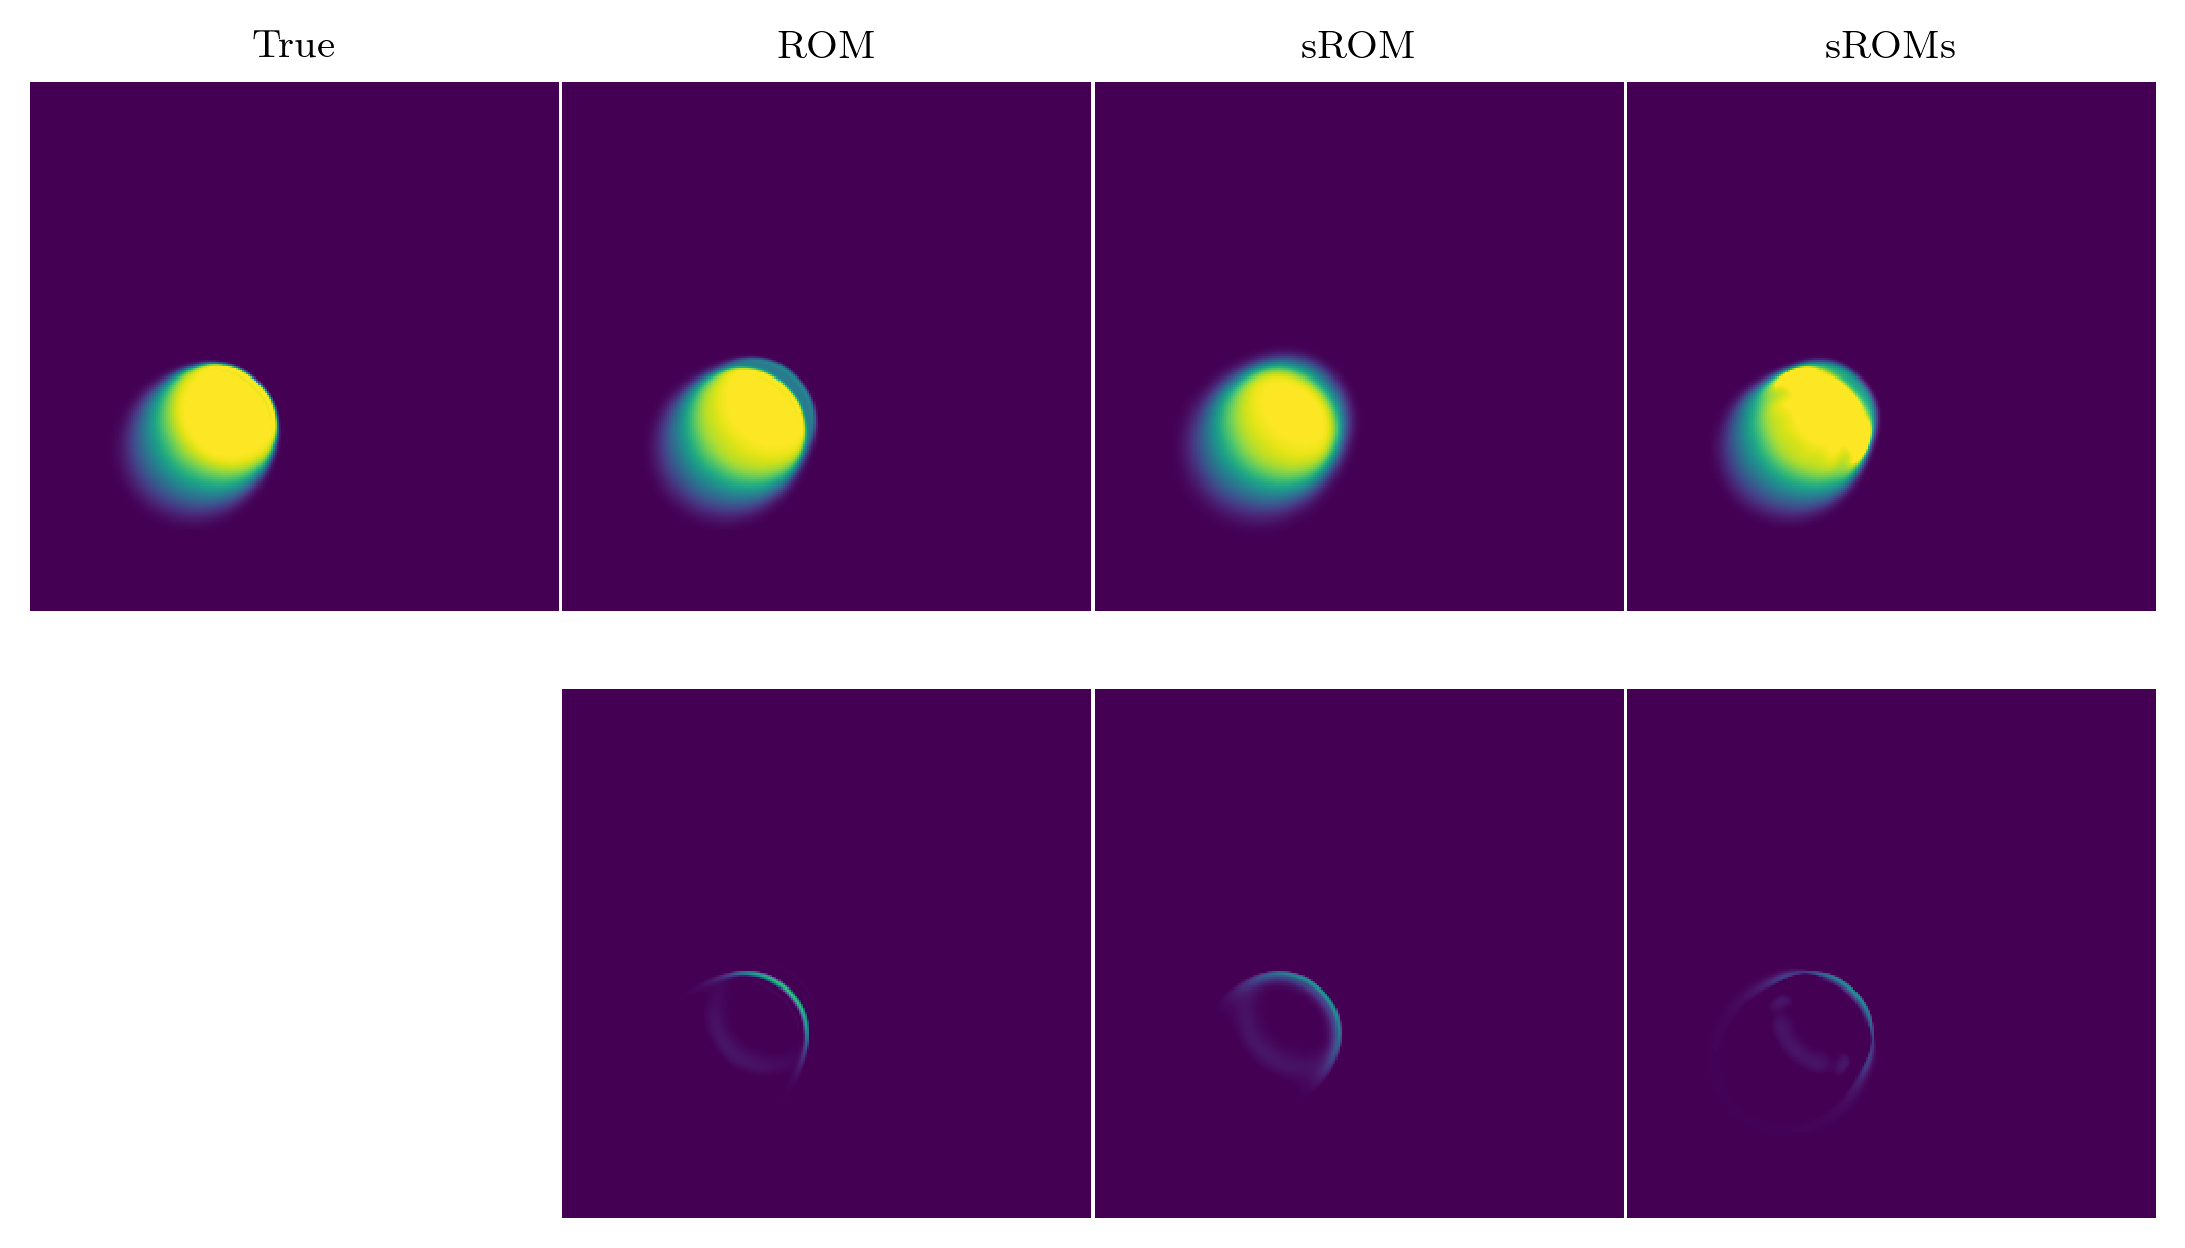

7 [0.083] 0.028825896560019843 0.028917518904751027 0.01648694201413605 -42.80510241959773


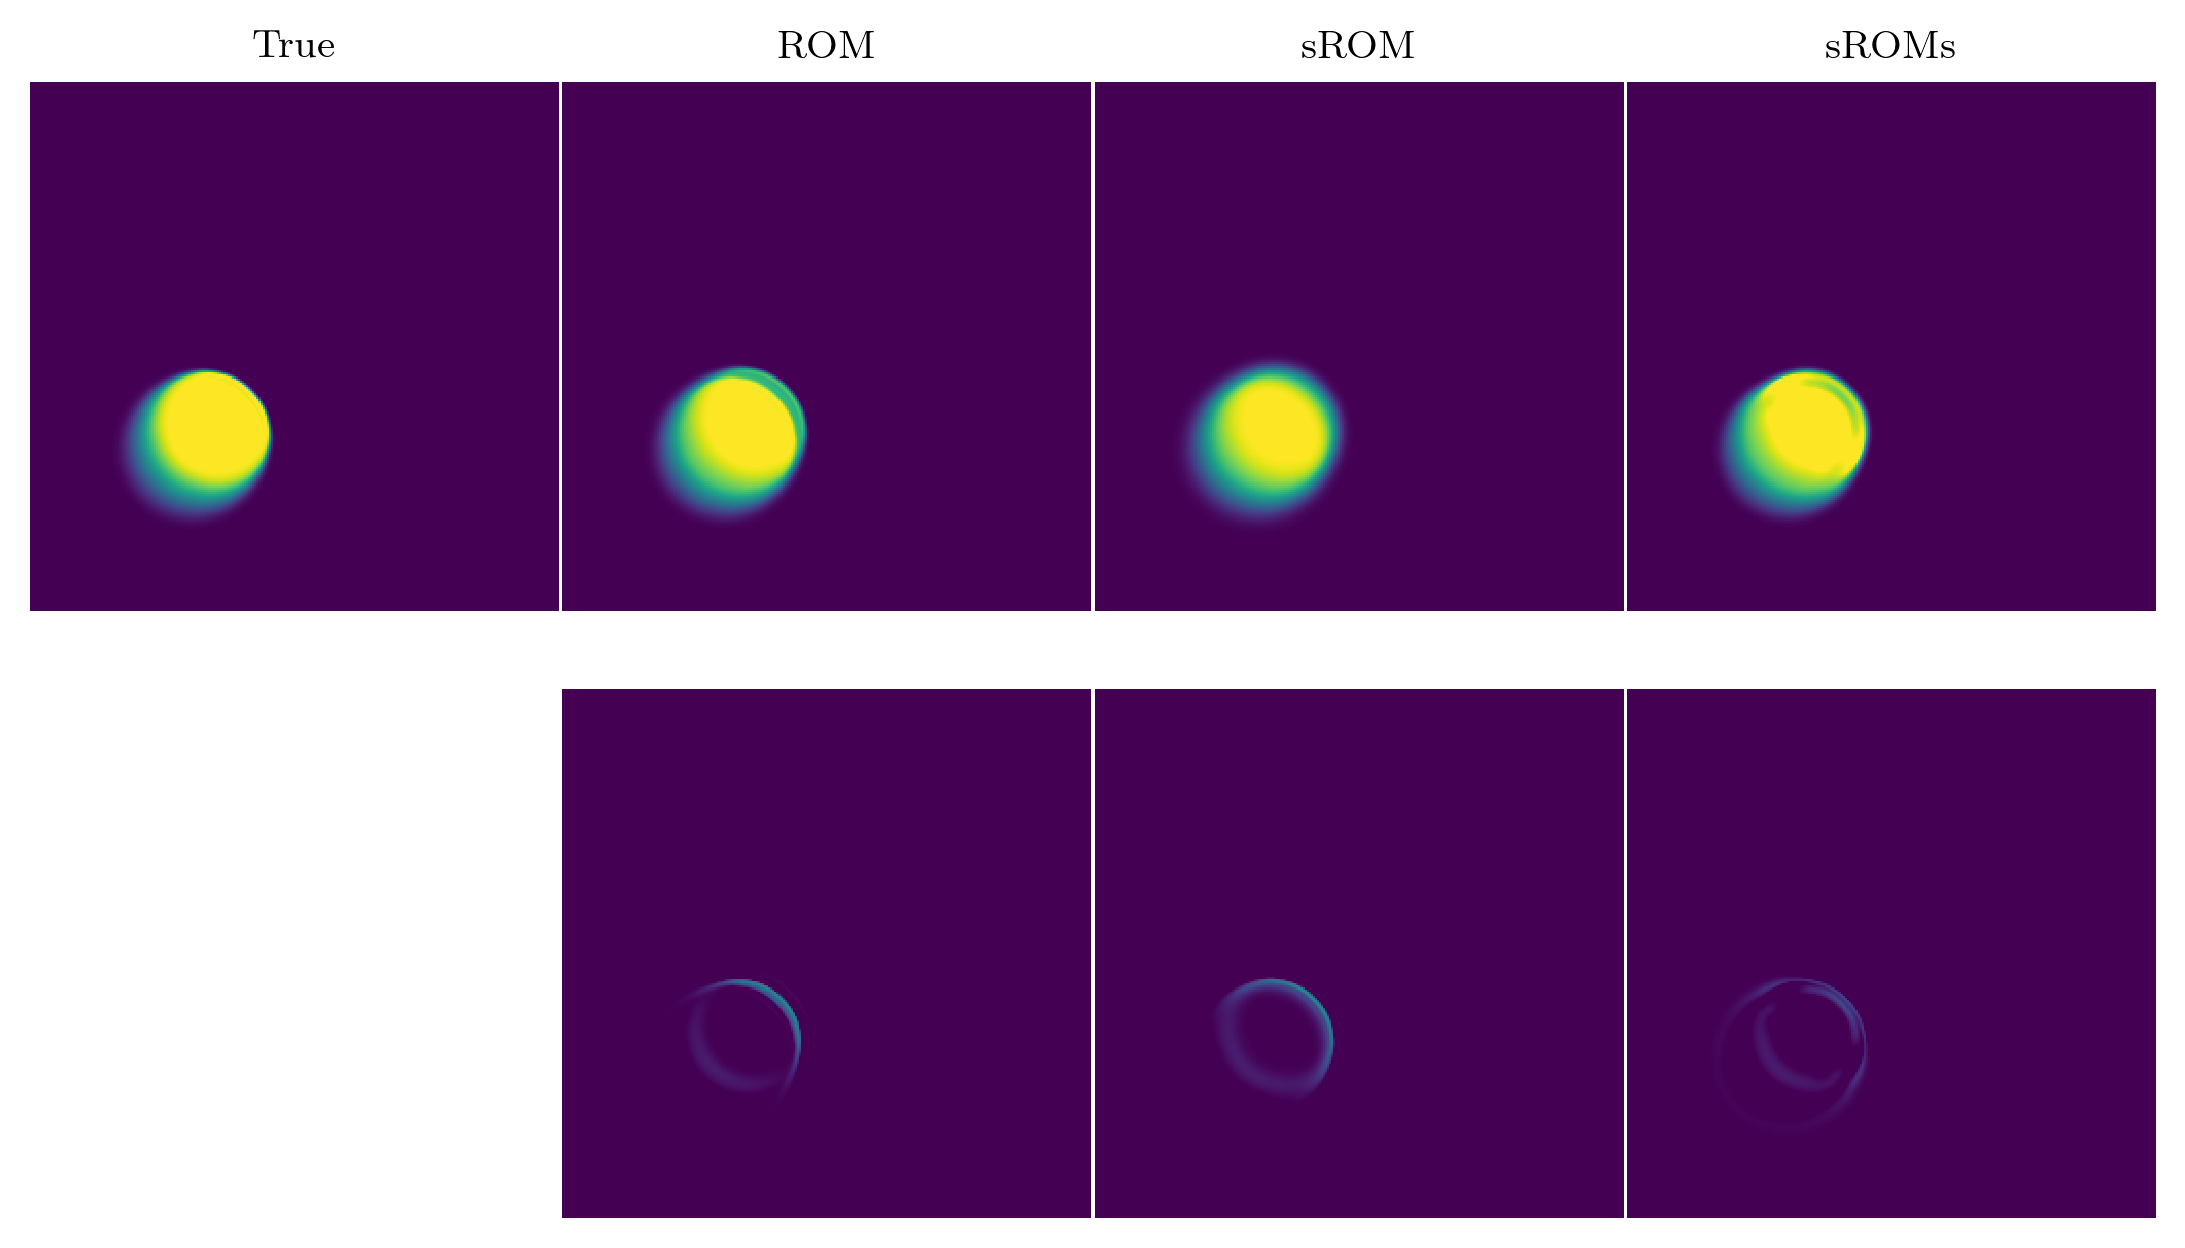

8 [0.611] 0.010104999573614033 0.015644648609916375 0.01014282585888793 0.37433237872339475


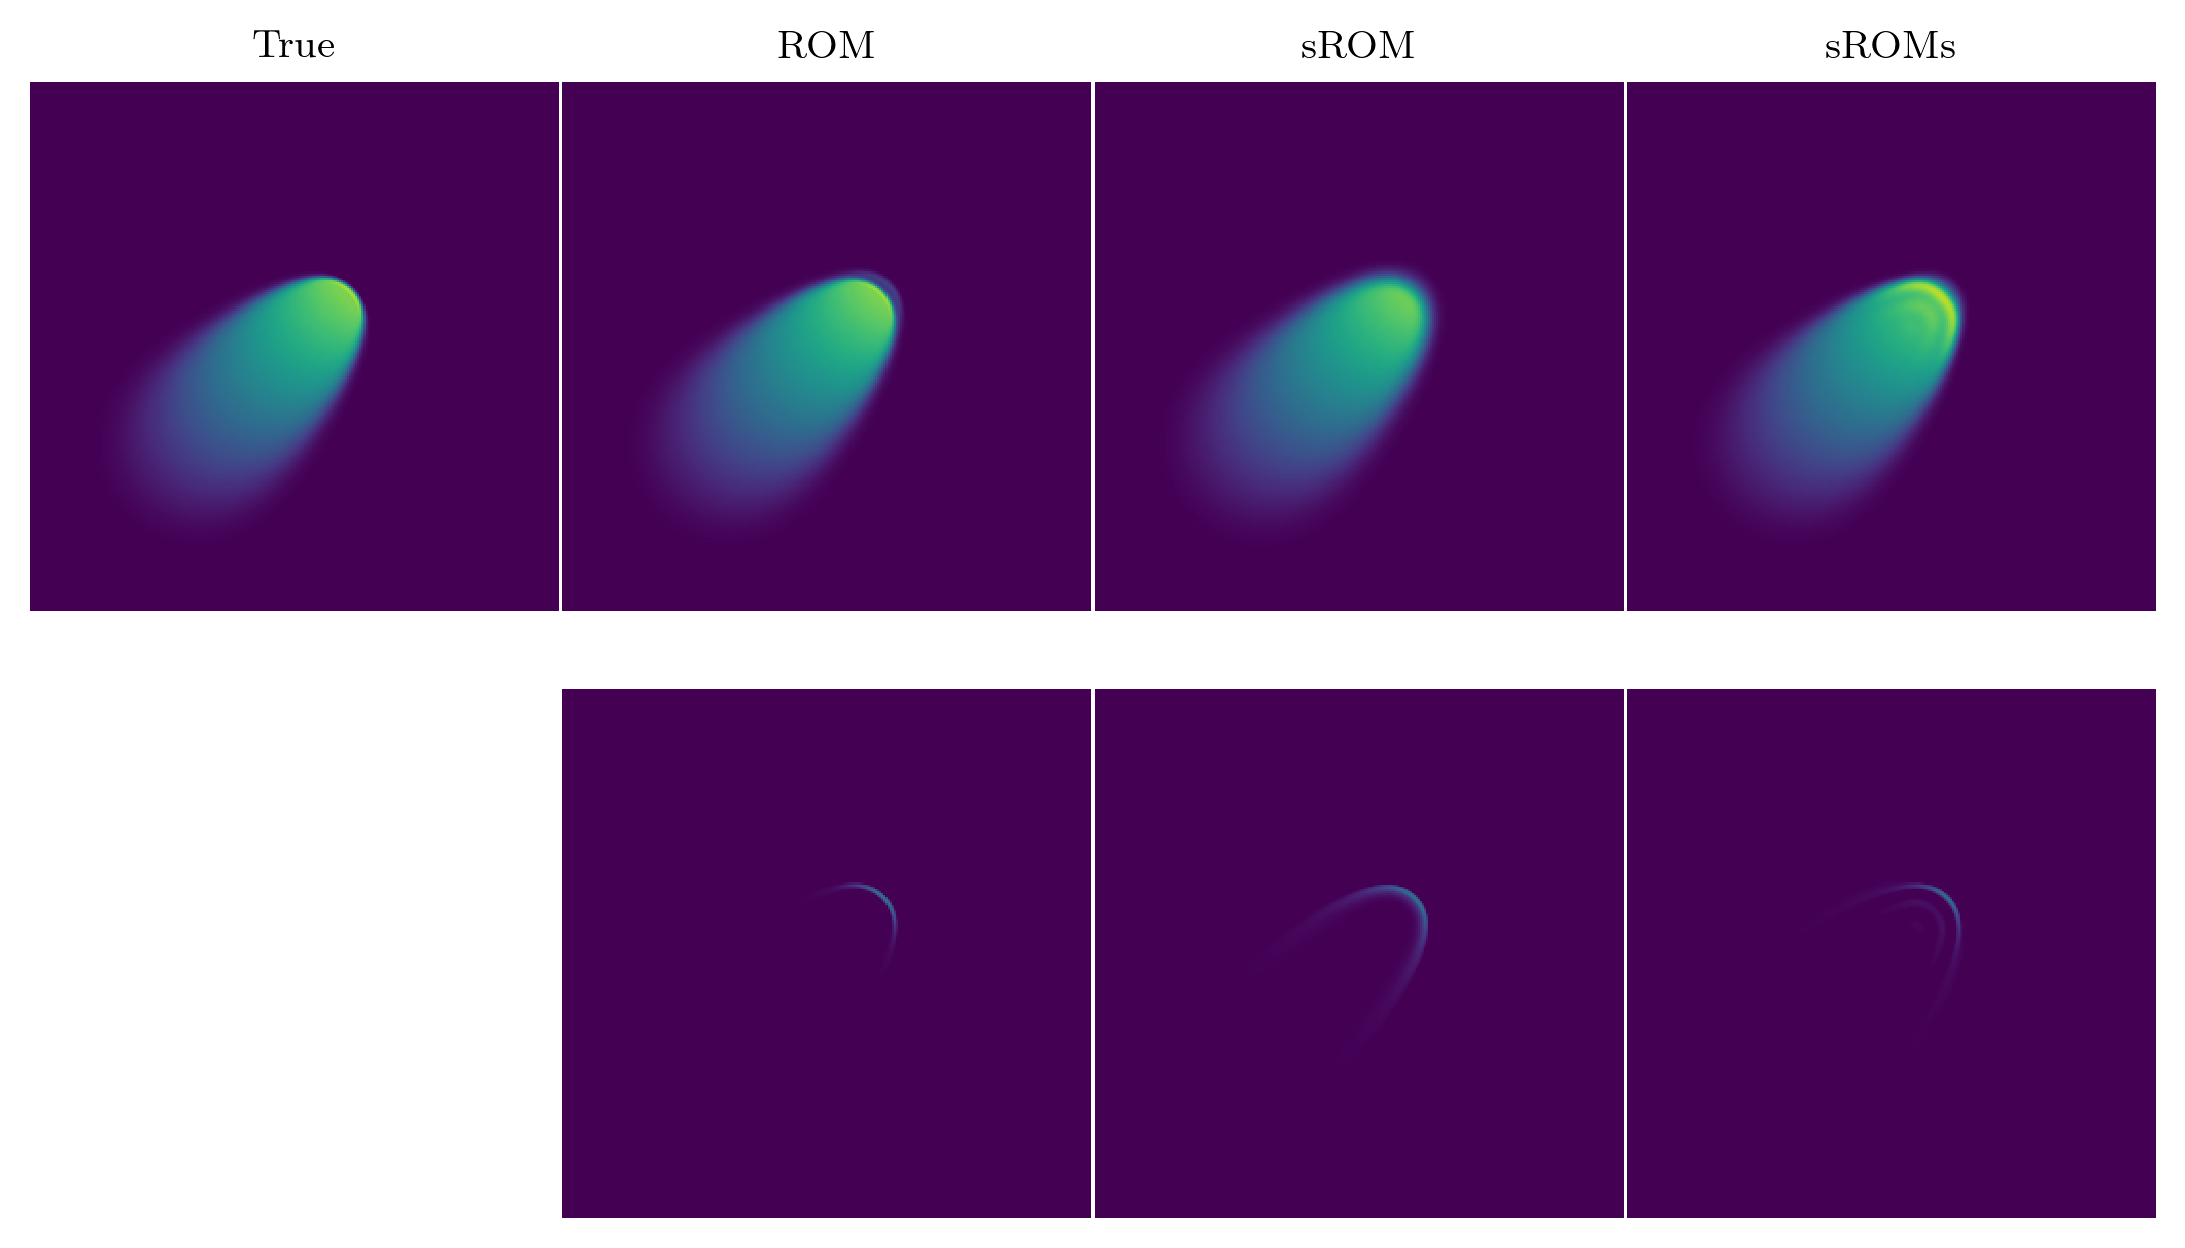

9 [0.486] 0.017240881882947933 0.019993001287082805 0.008703181366350959 -49.52009168998004


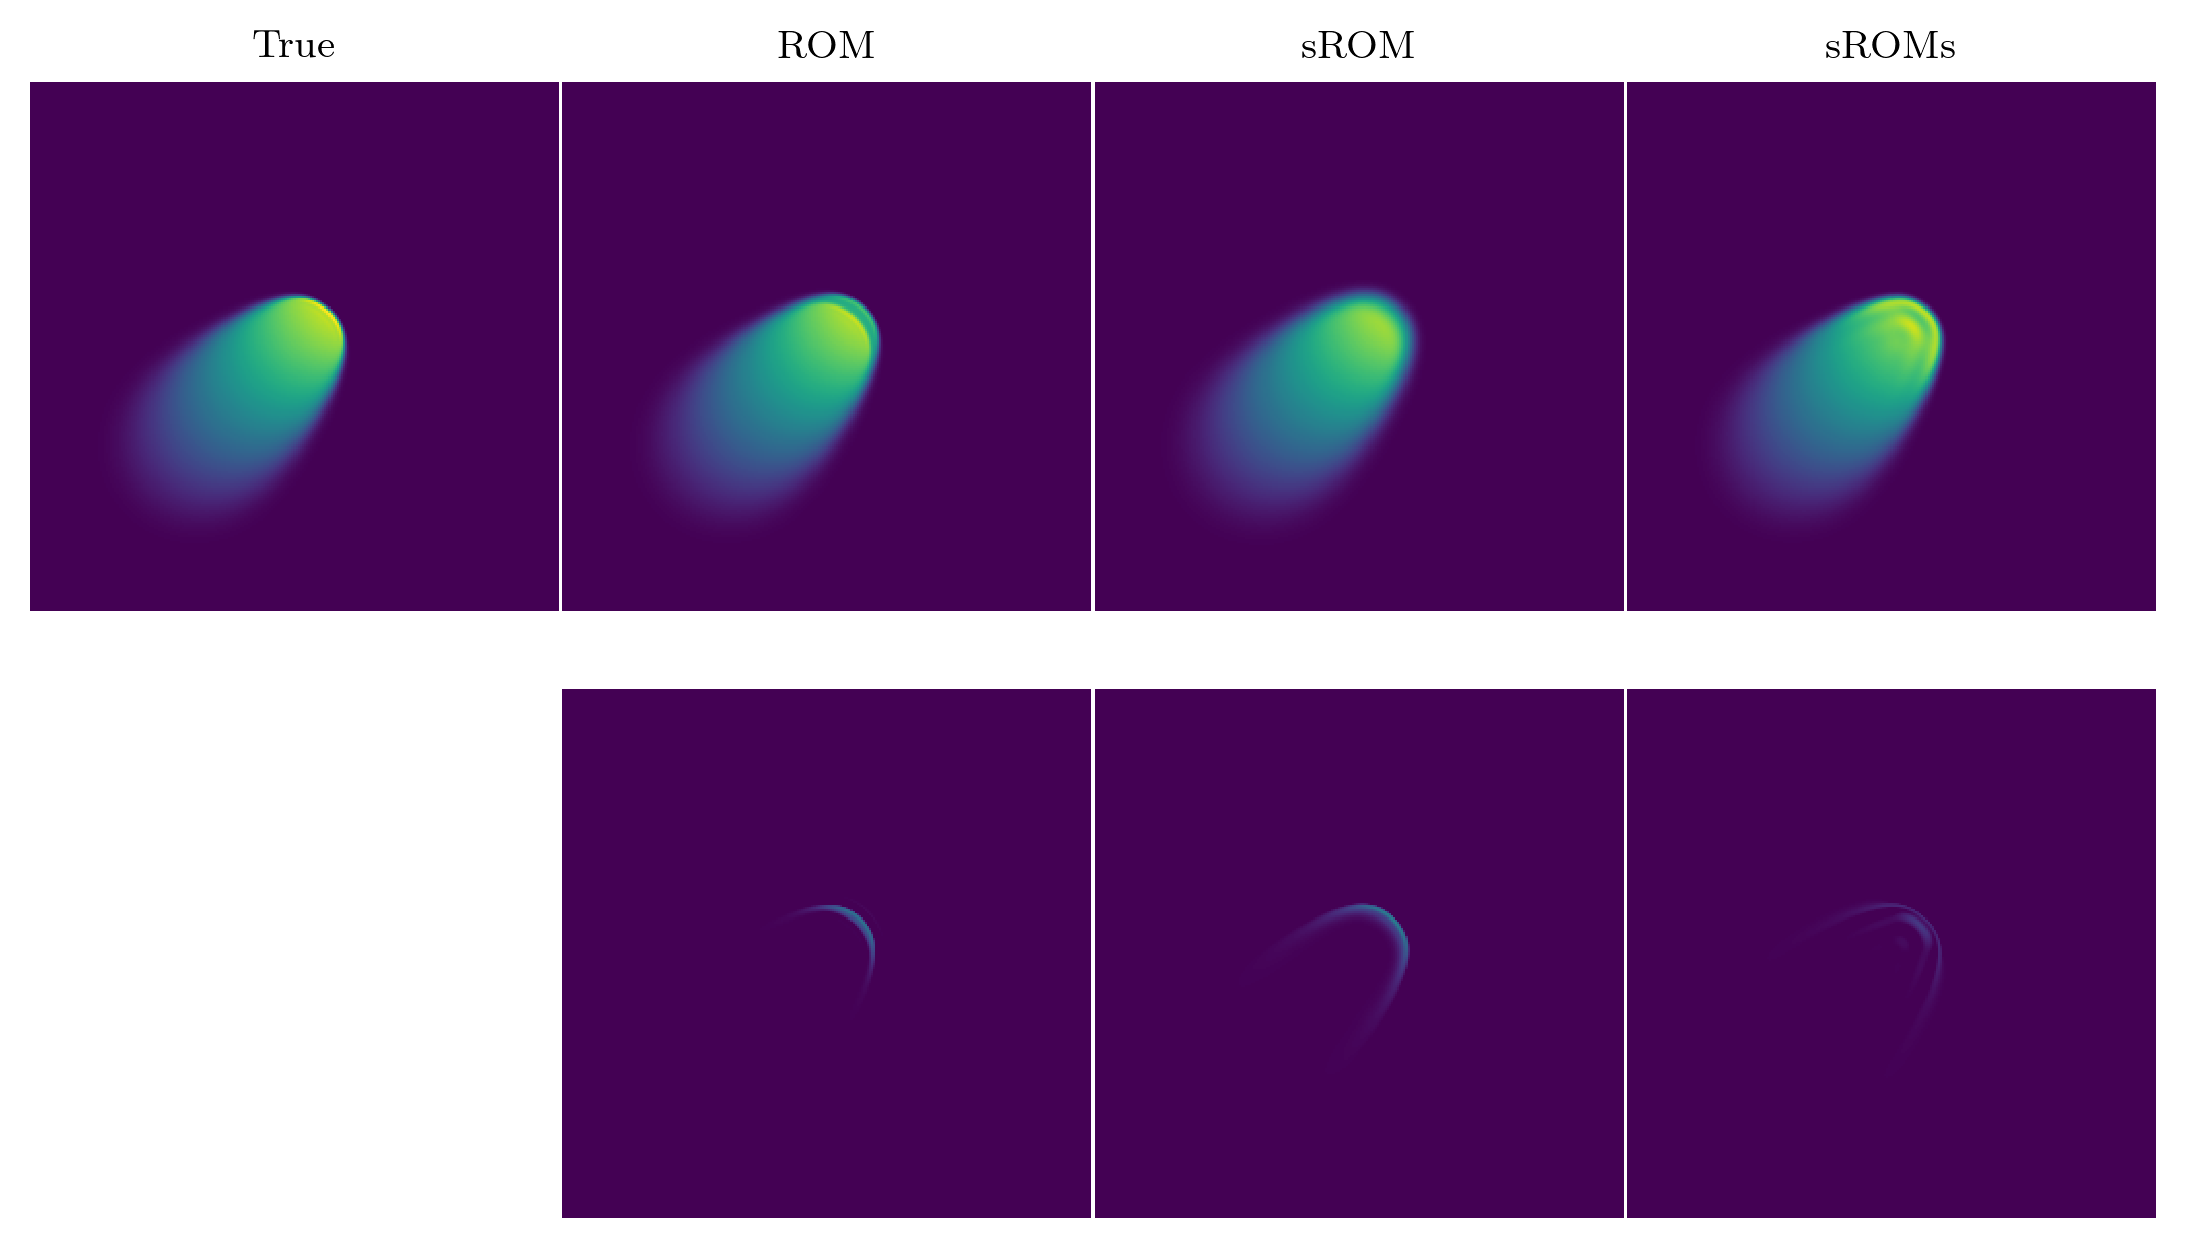

10 [0.405] 0.009546819010058043 0.020129711853688528 0.012618811929023643 32.17818328522941


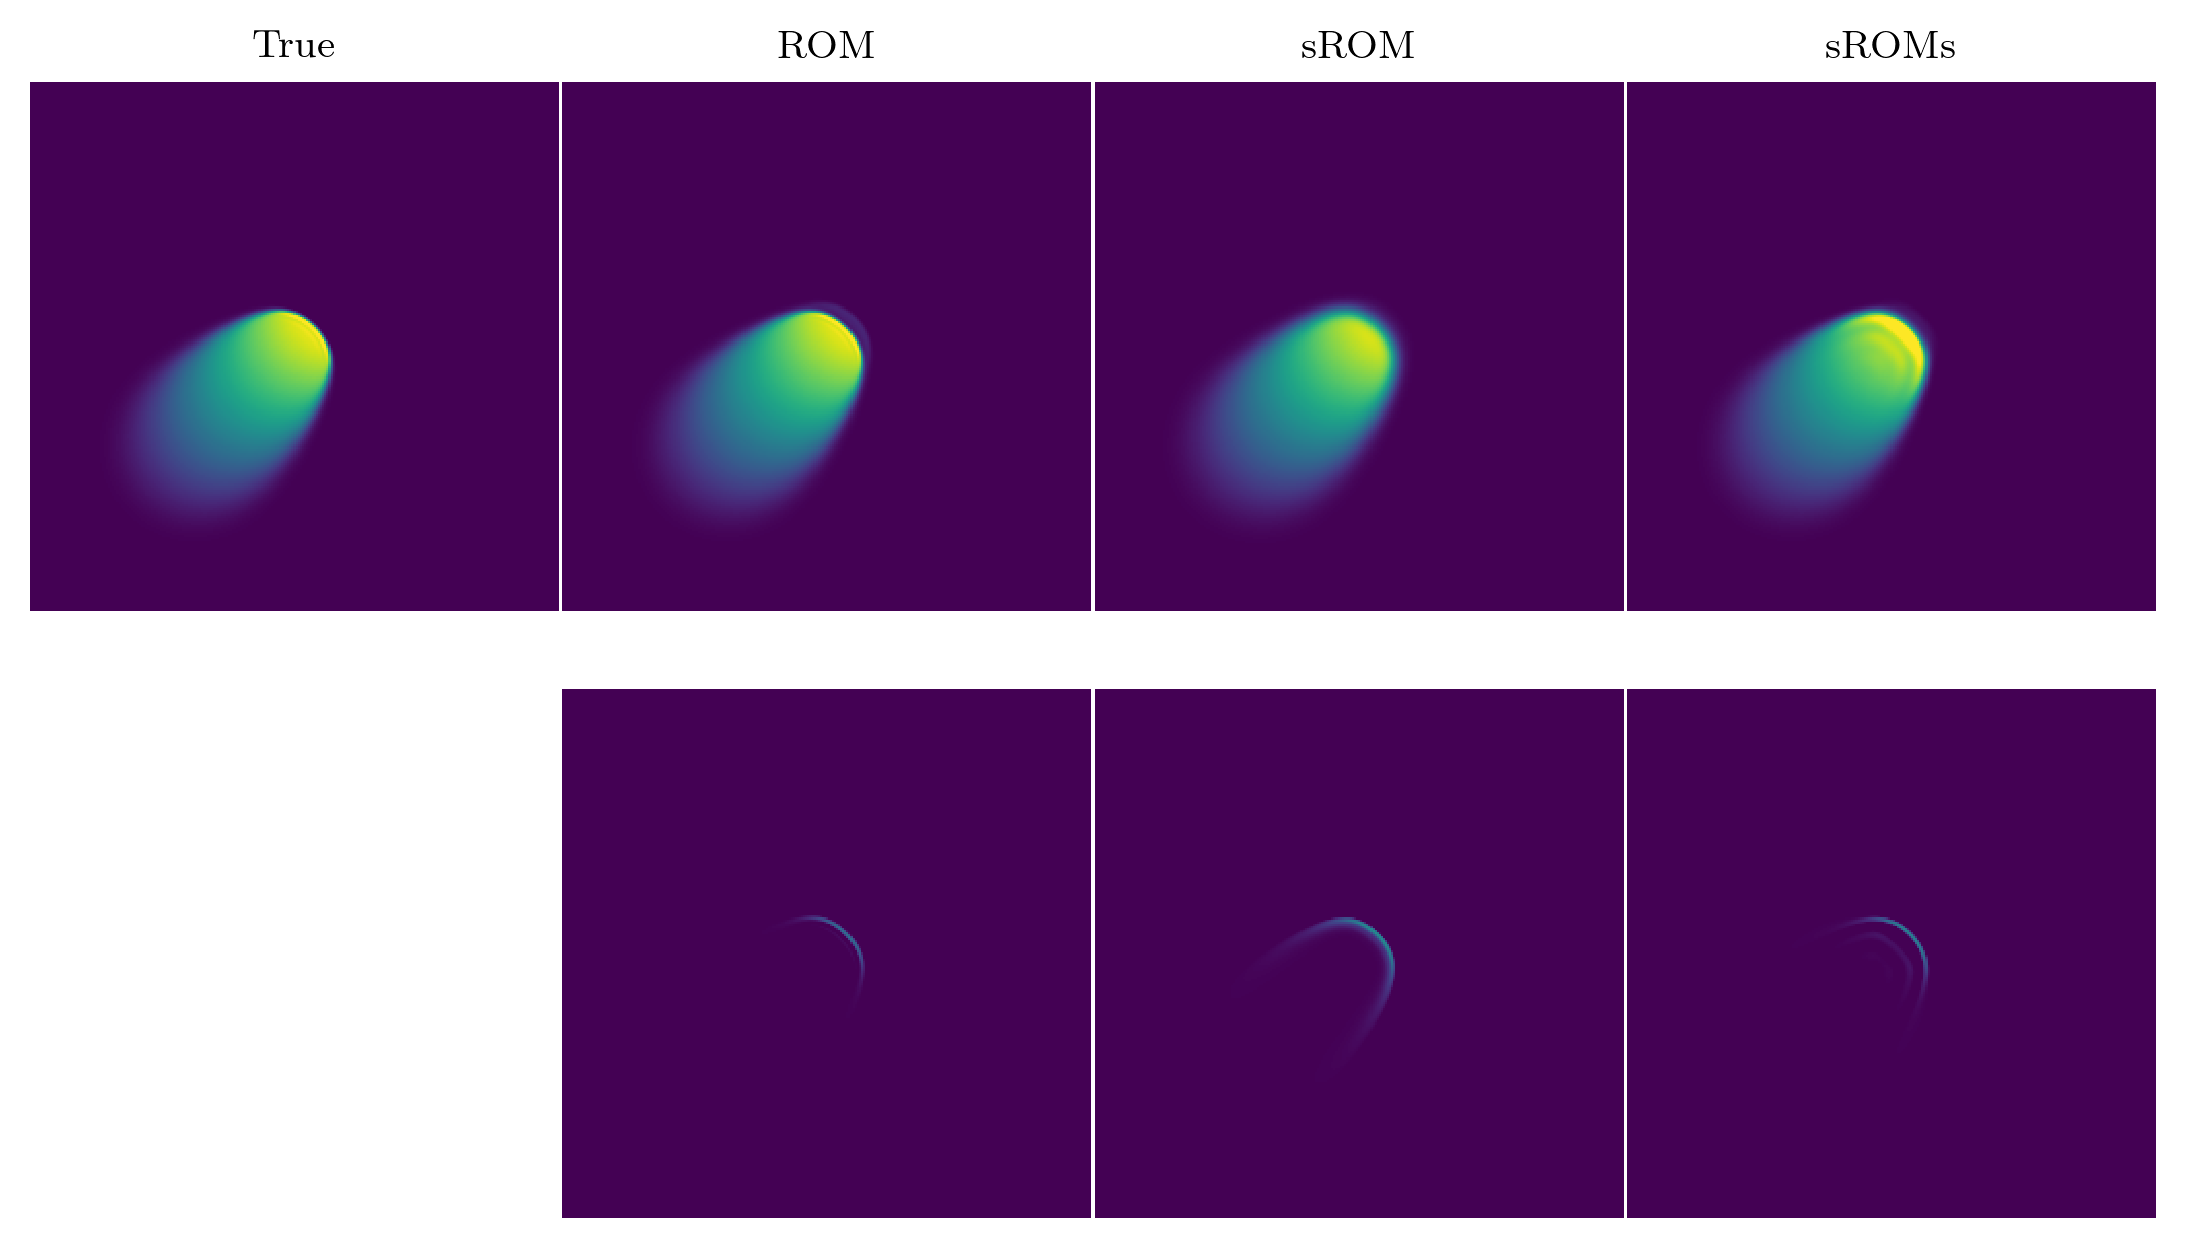

11 [0.08] 0.03053831796678402 0.029590435575796468 0.018483810537505526 -39.473383708919286


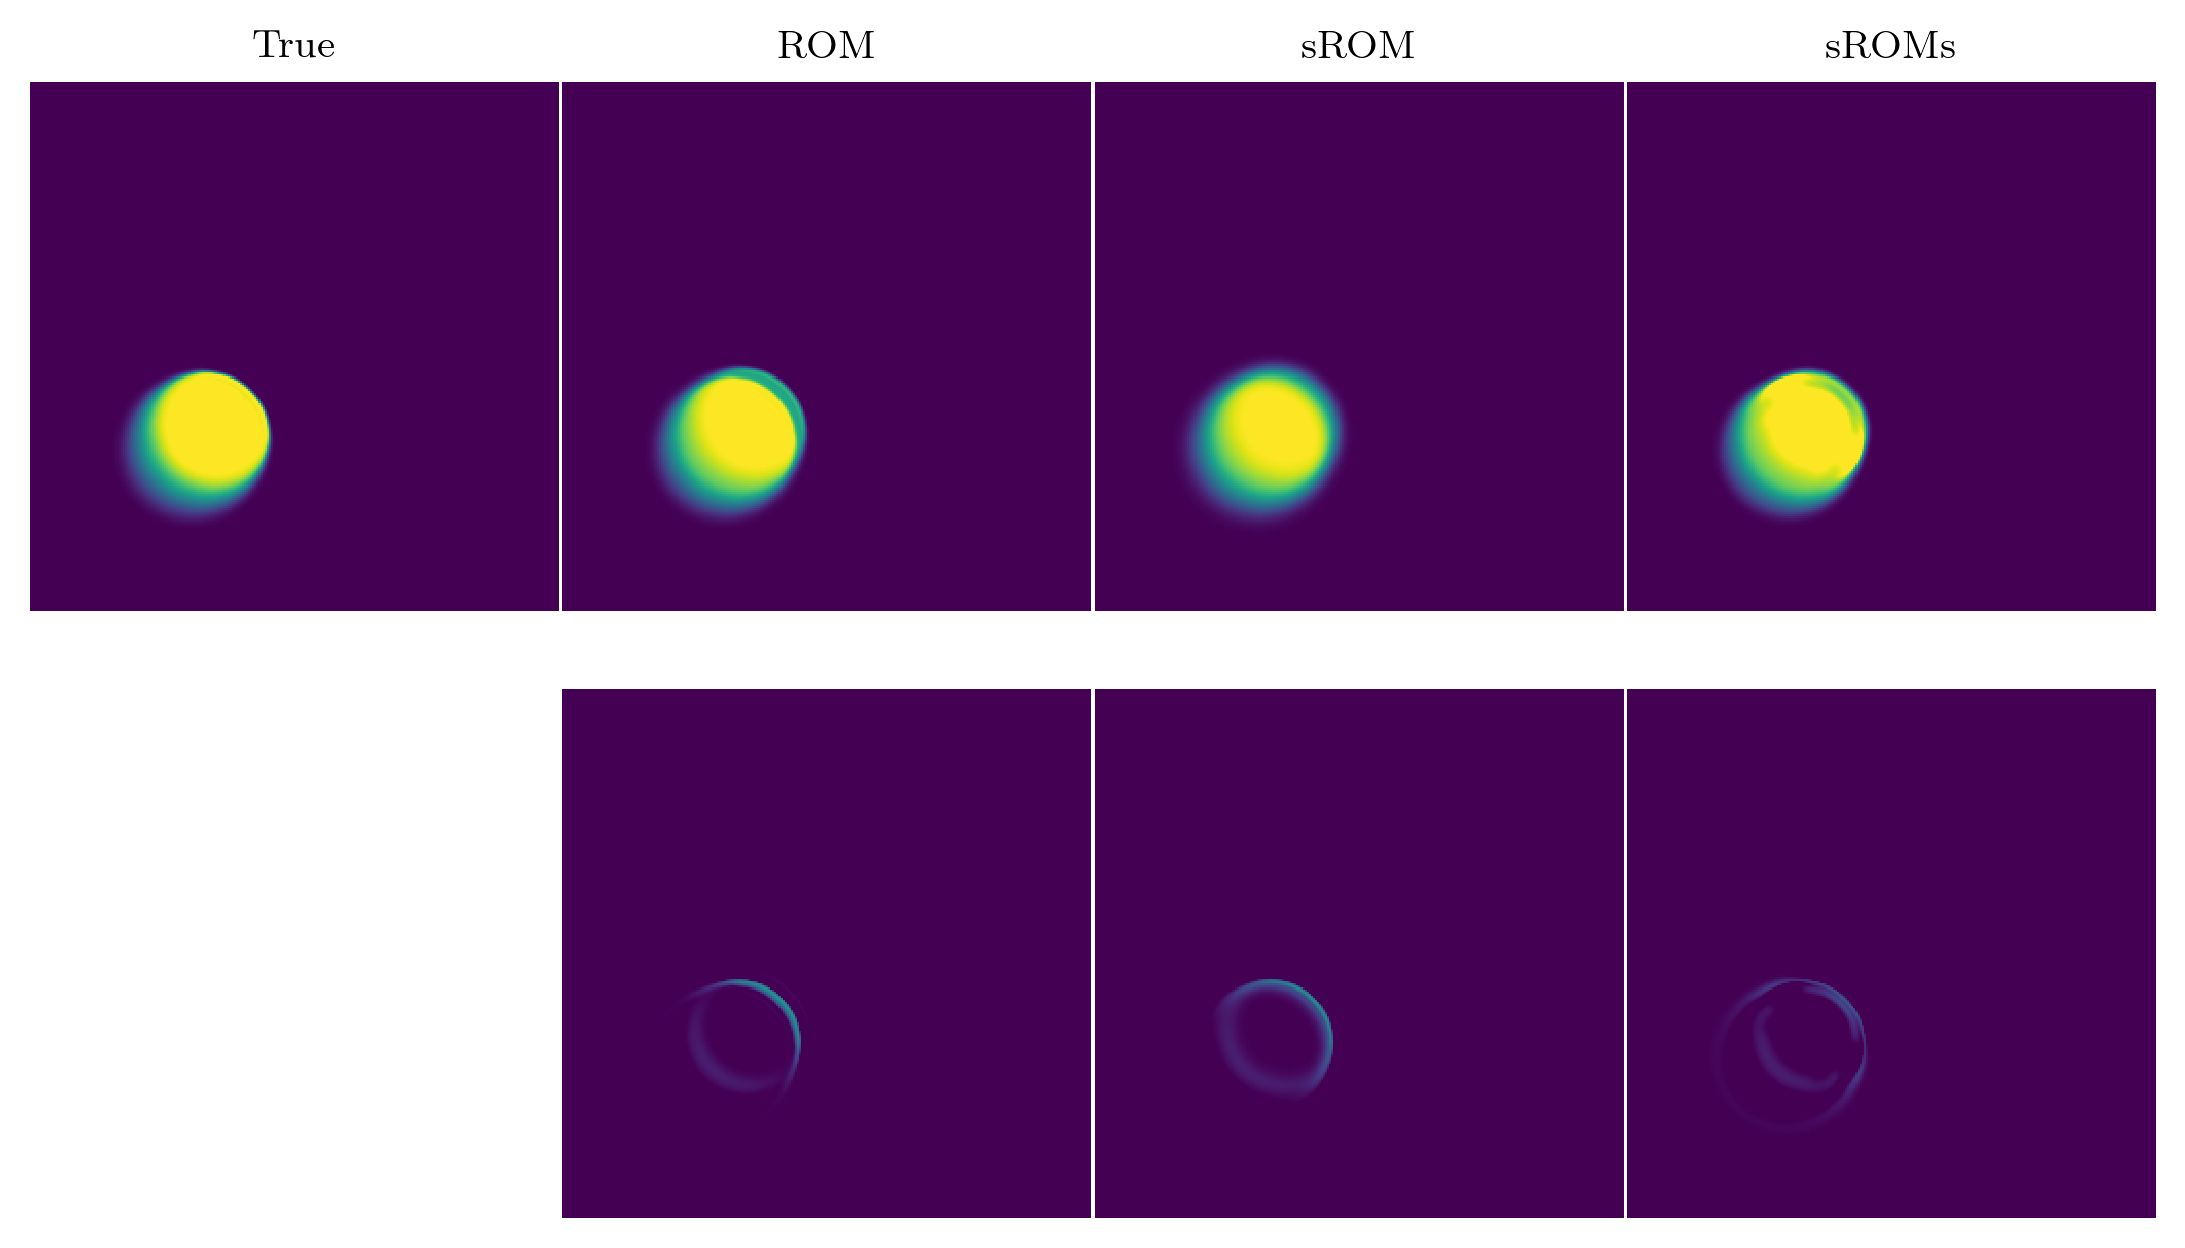

12 [0.428] 0.024212581049885218 0.02333108254470751 0.015080940881634492 -37.71444336907657


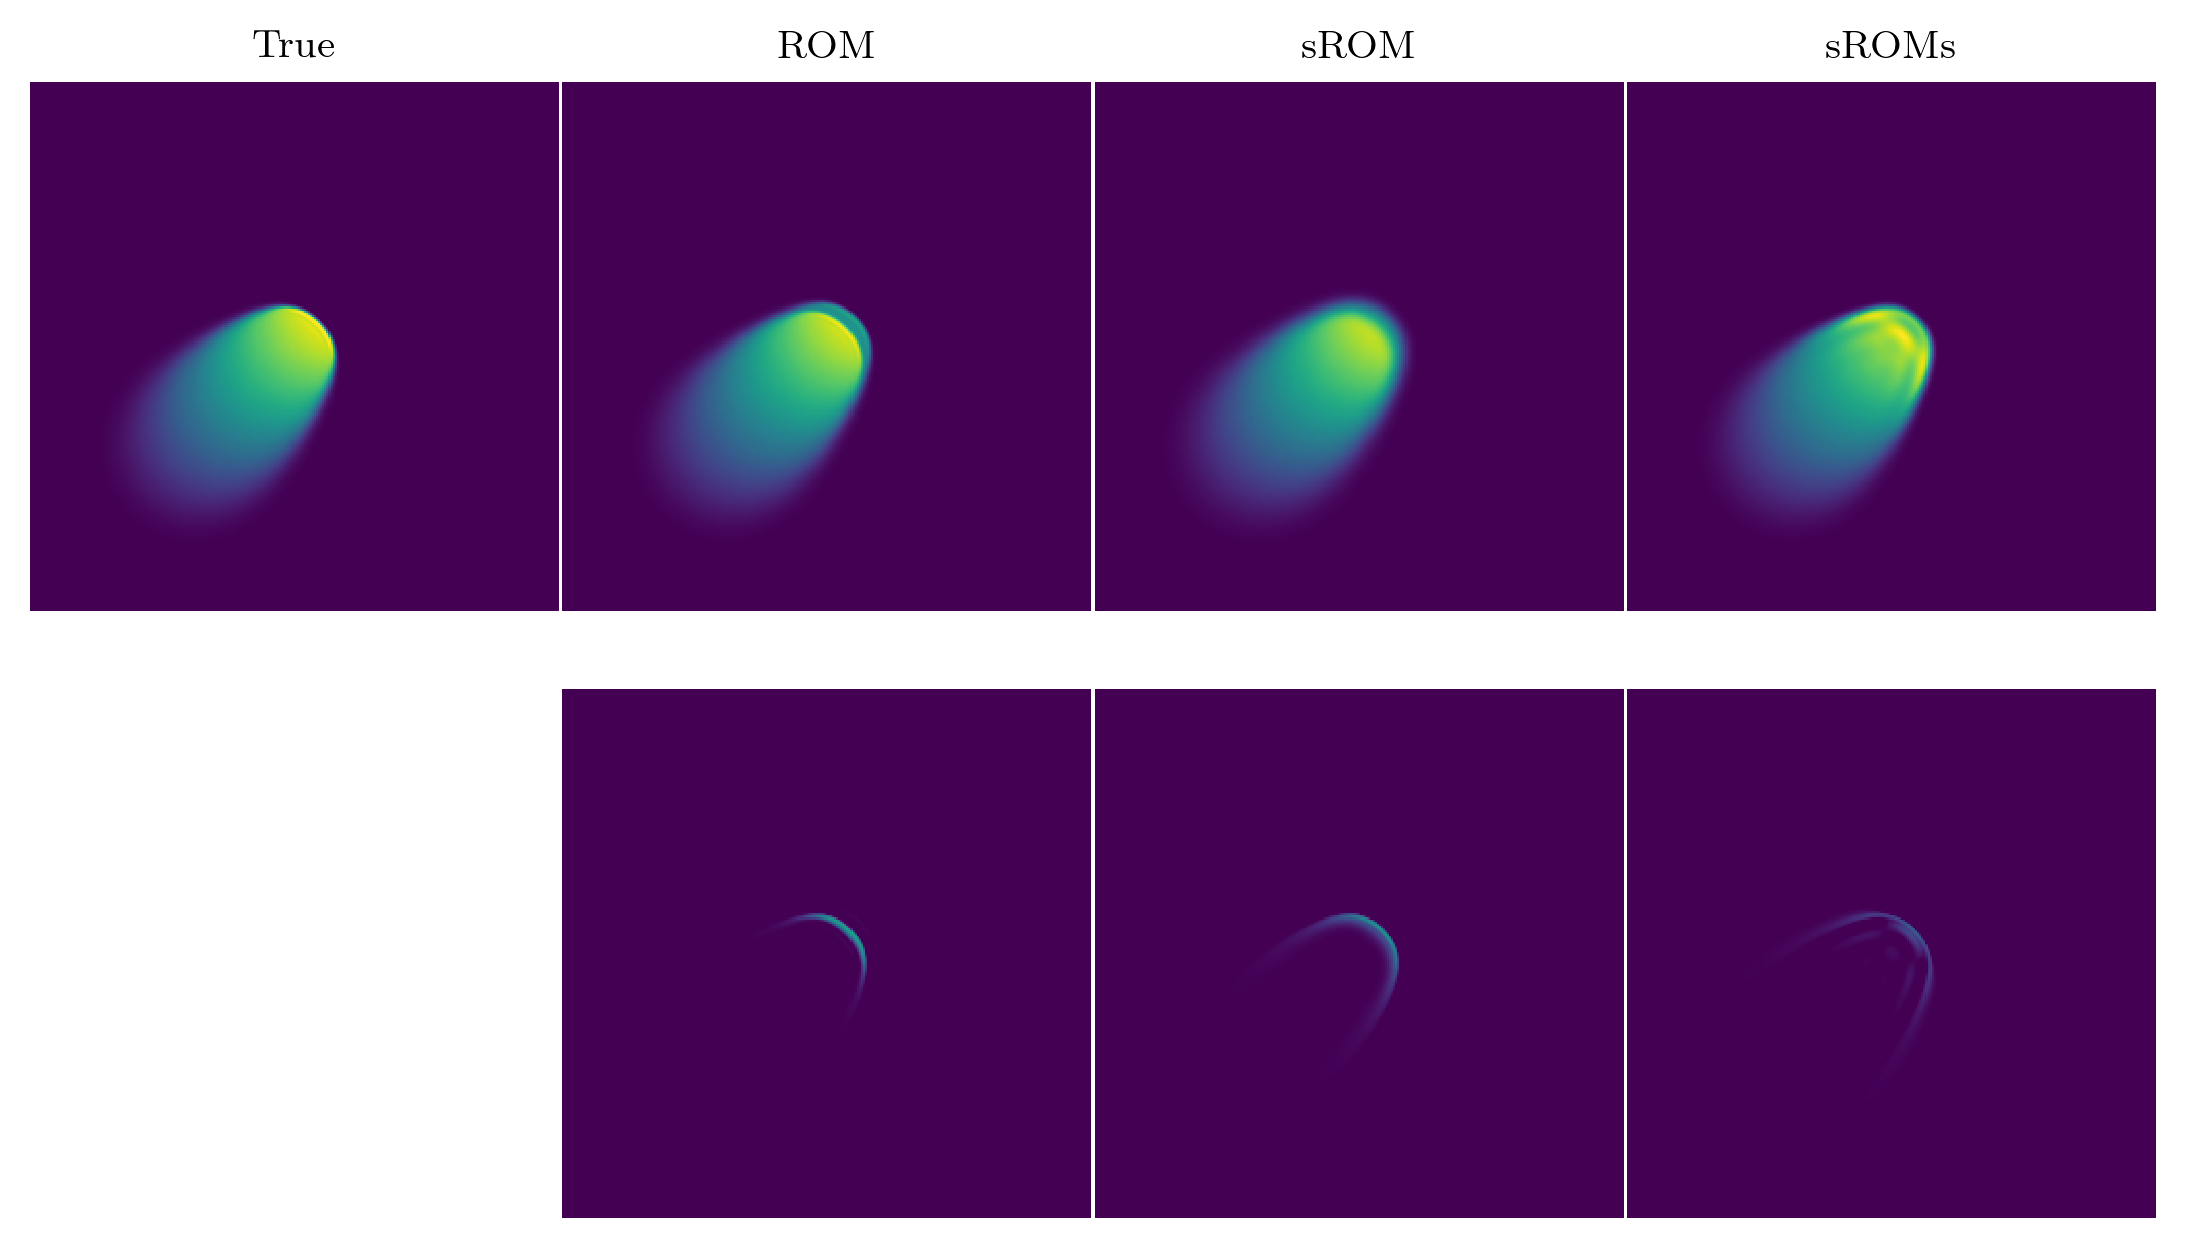

13 [0.804] 0.0024999035676765697 0.01141626154851027 0.004858913775078214 94.36404819383199


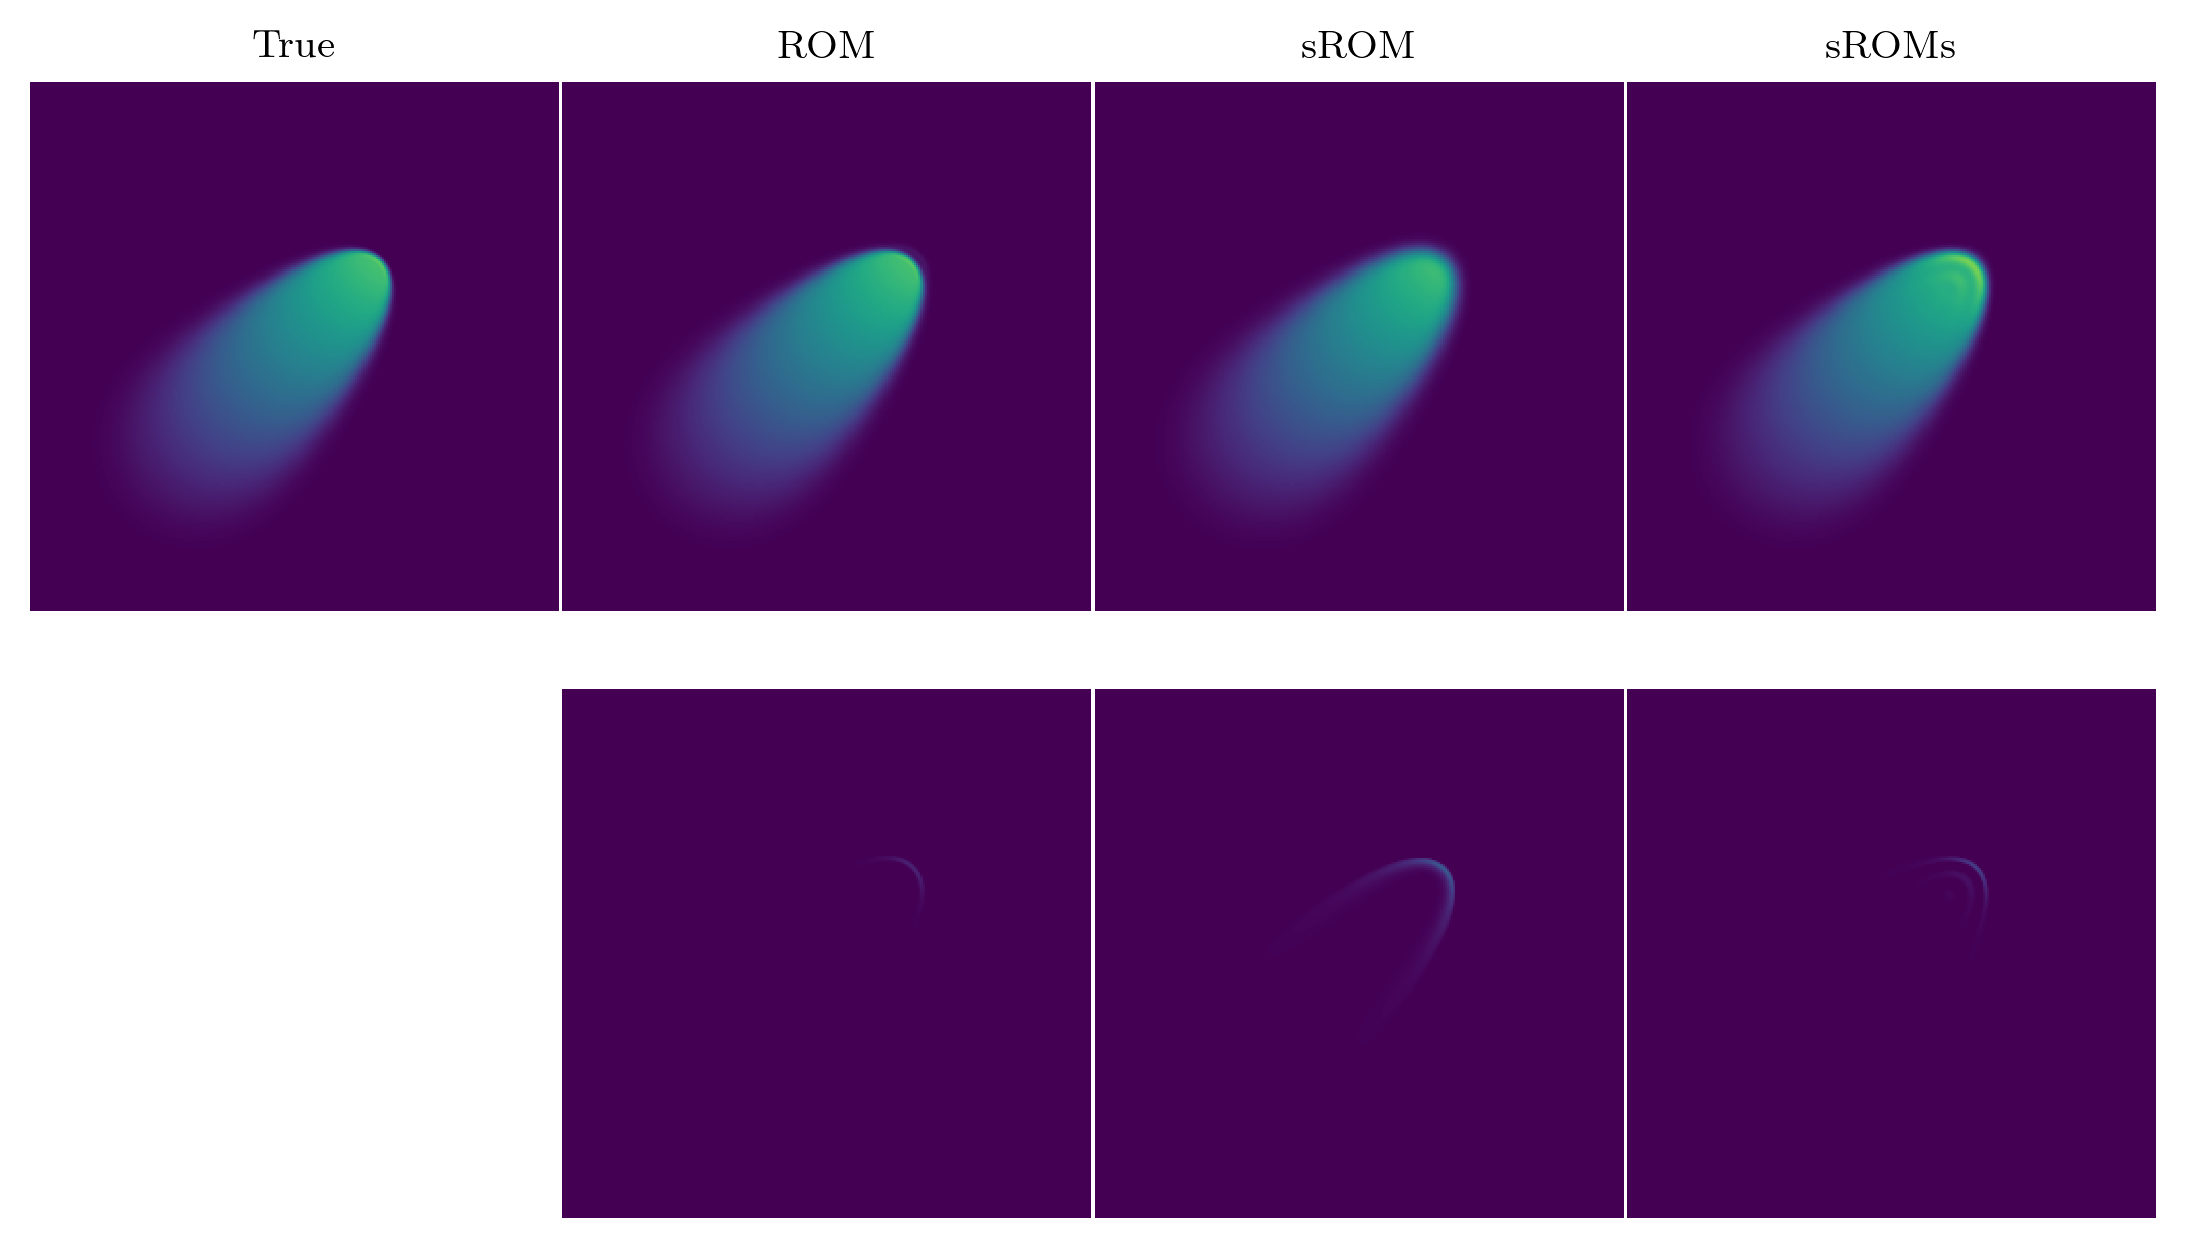

14 [0.088] 0.02382340330817473 0.027273856762331718 0.012508040392443059 -47.49683649039738


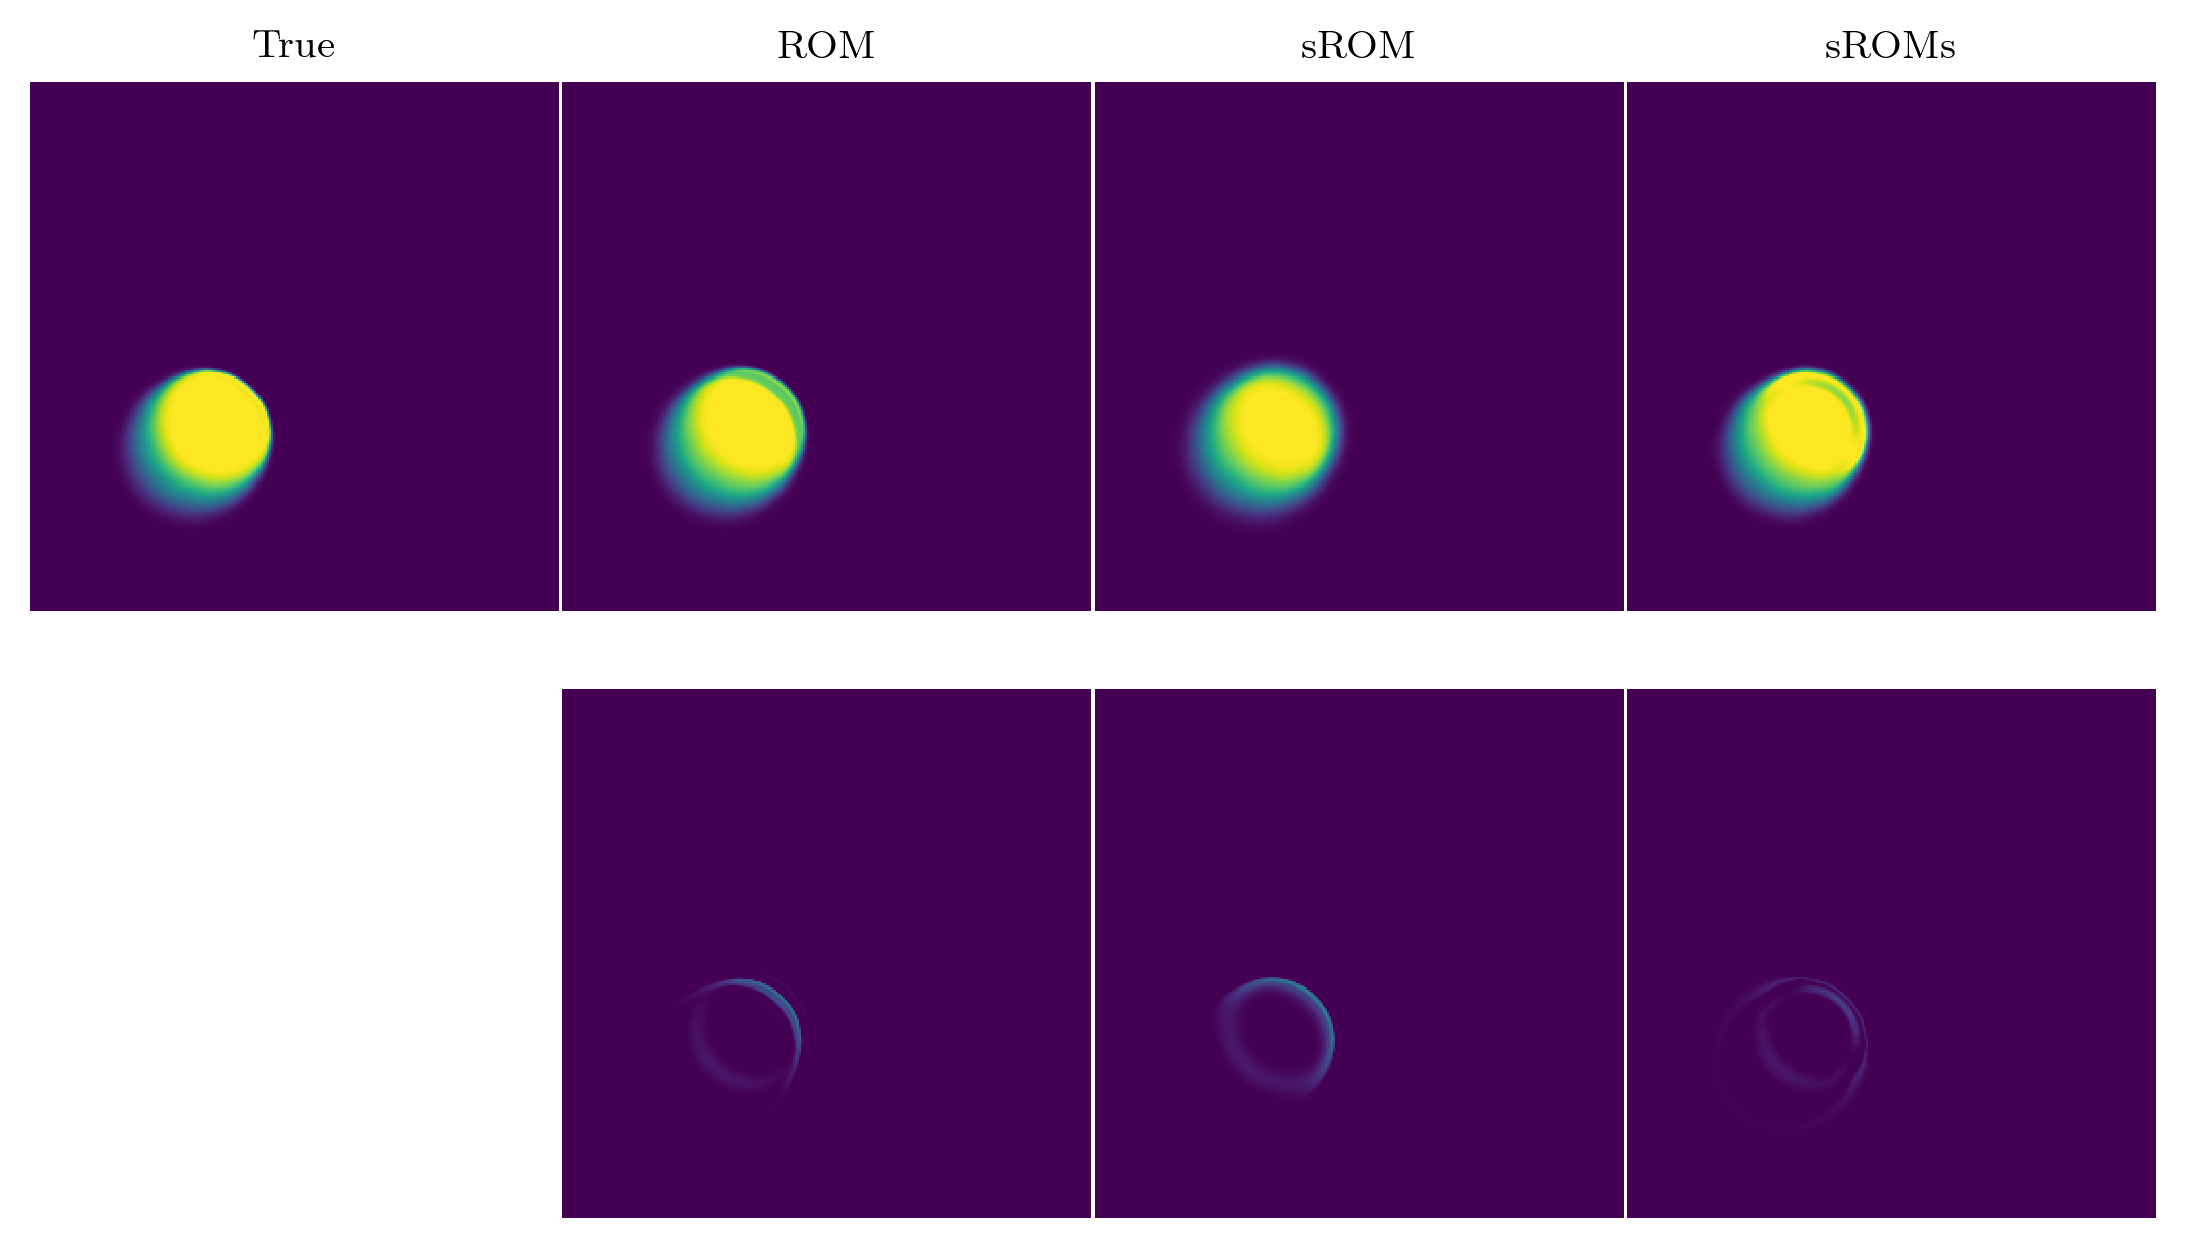

15 [0.694] 0.004964616122897282 0.01338736241156149 0.003543980718498634 -28.6152115134651


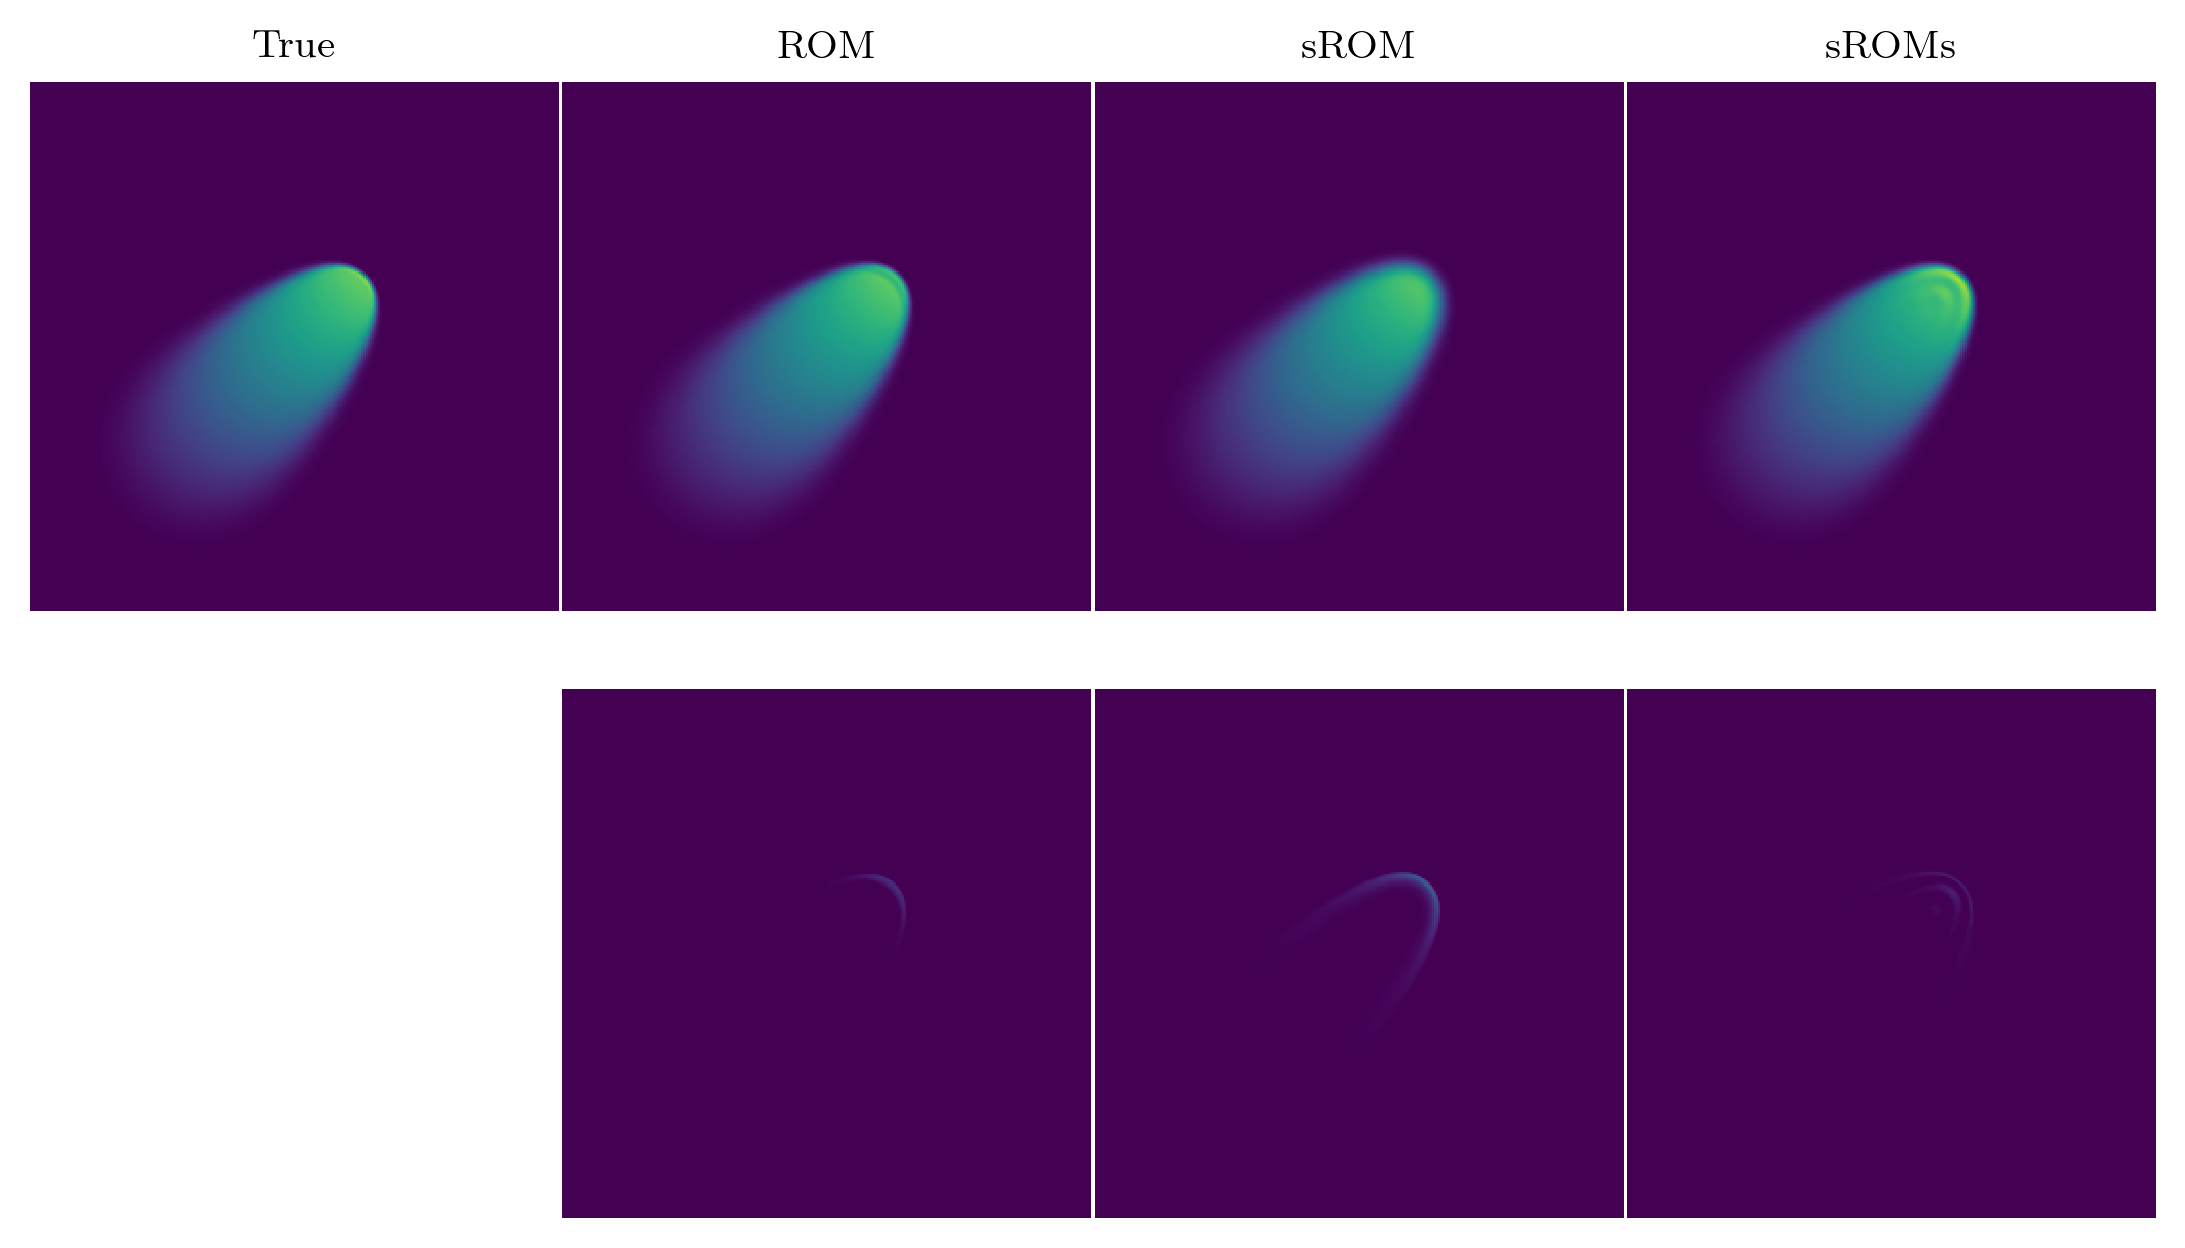

16 [0.744] 0.0043679539241008895 0.012565288264411638 0.003227707150828666 -26.104826037214536


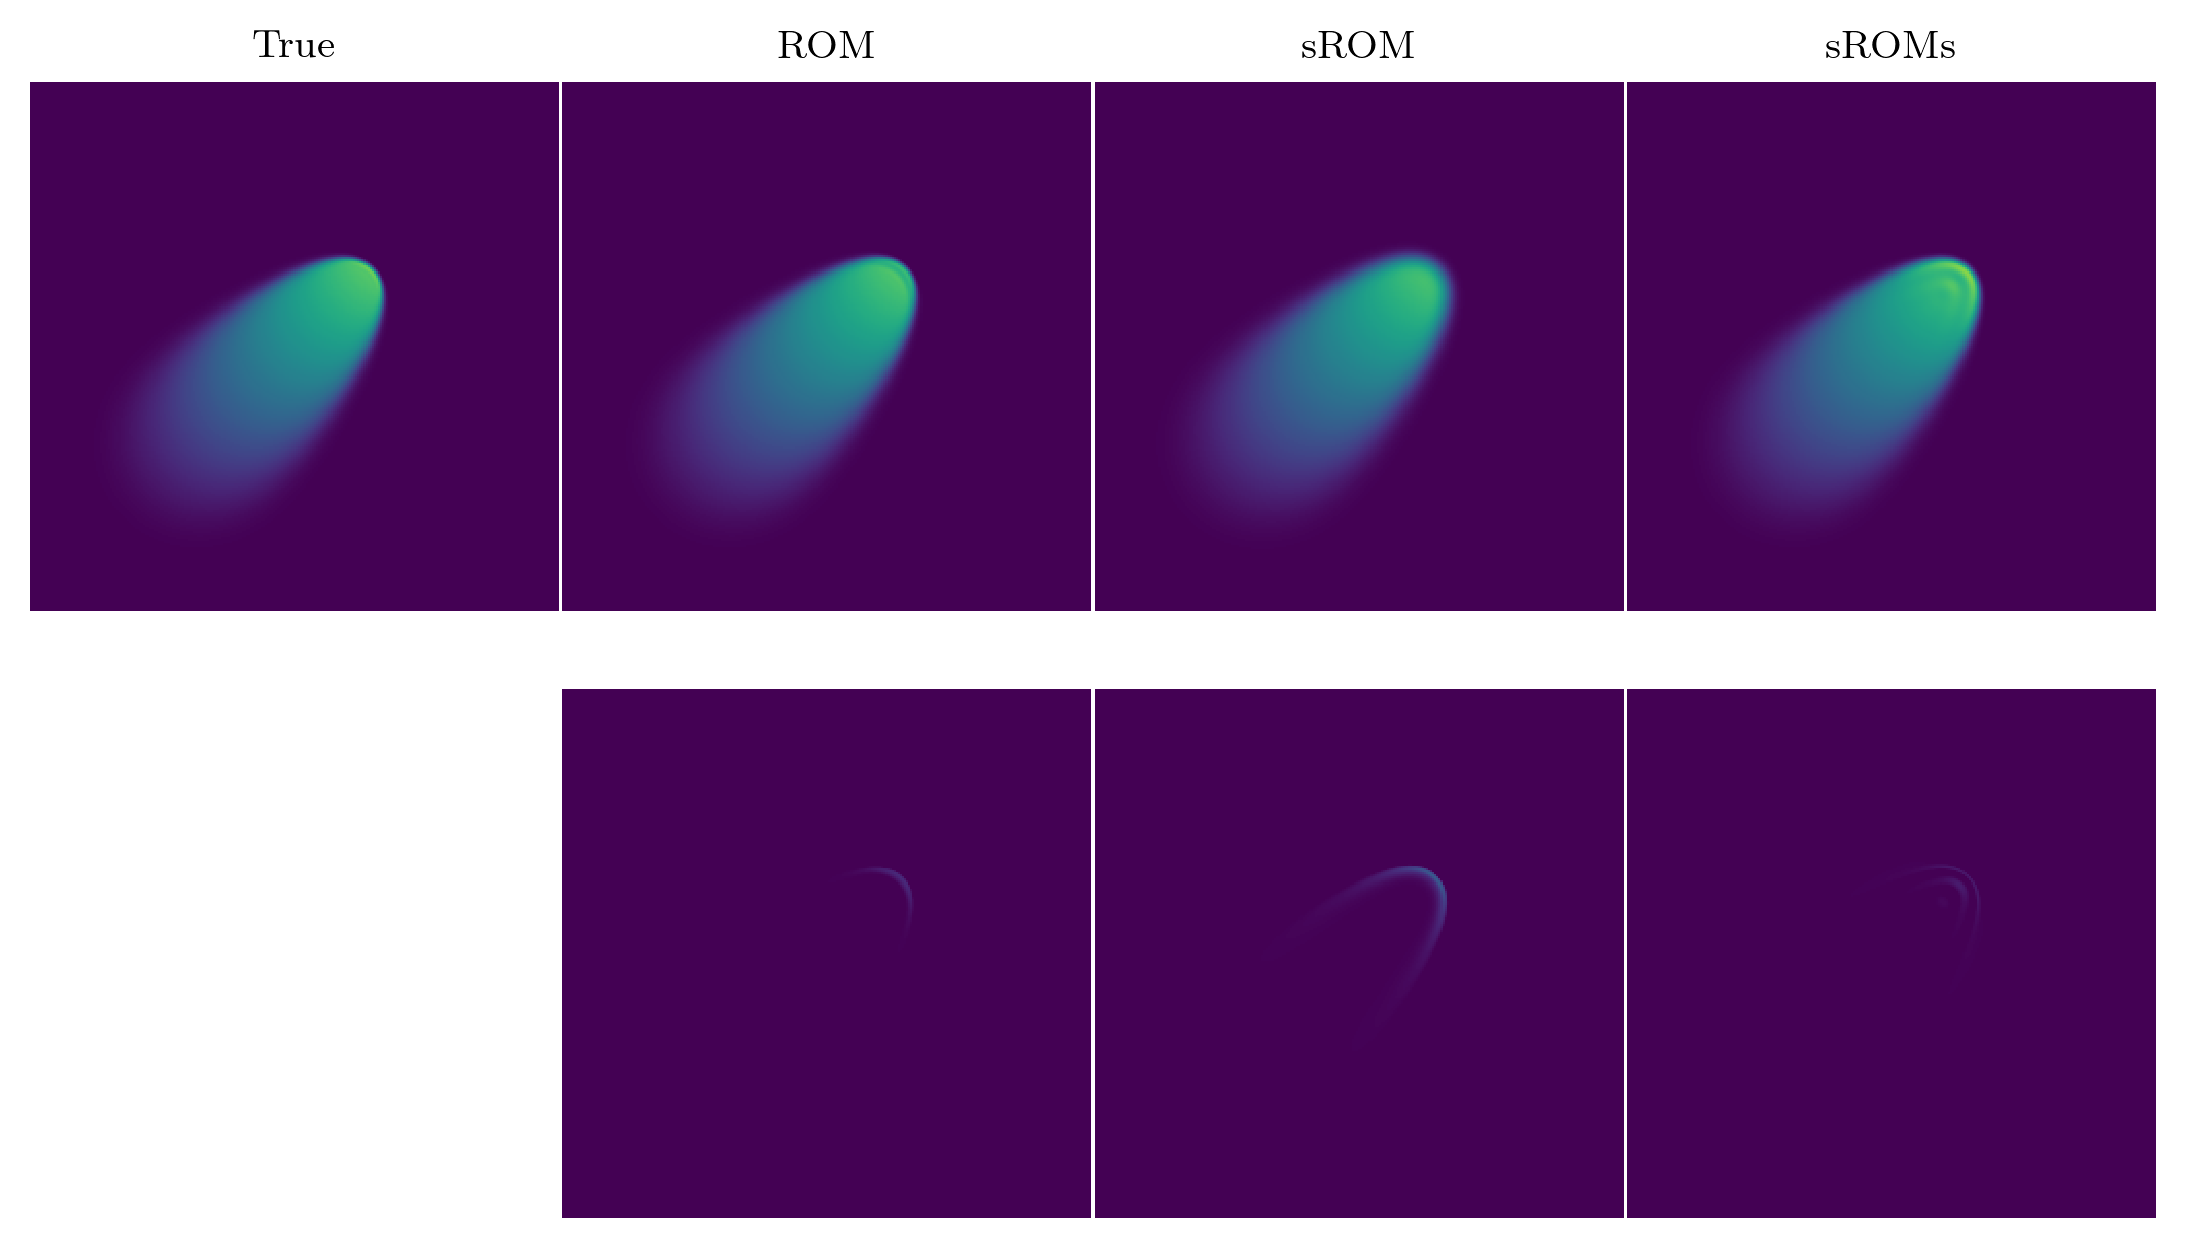

17 [0.41] 0.01690809084907005 0.021506894933985707 0.016700596017530427 -1.2271925517305533


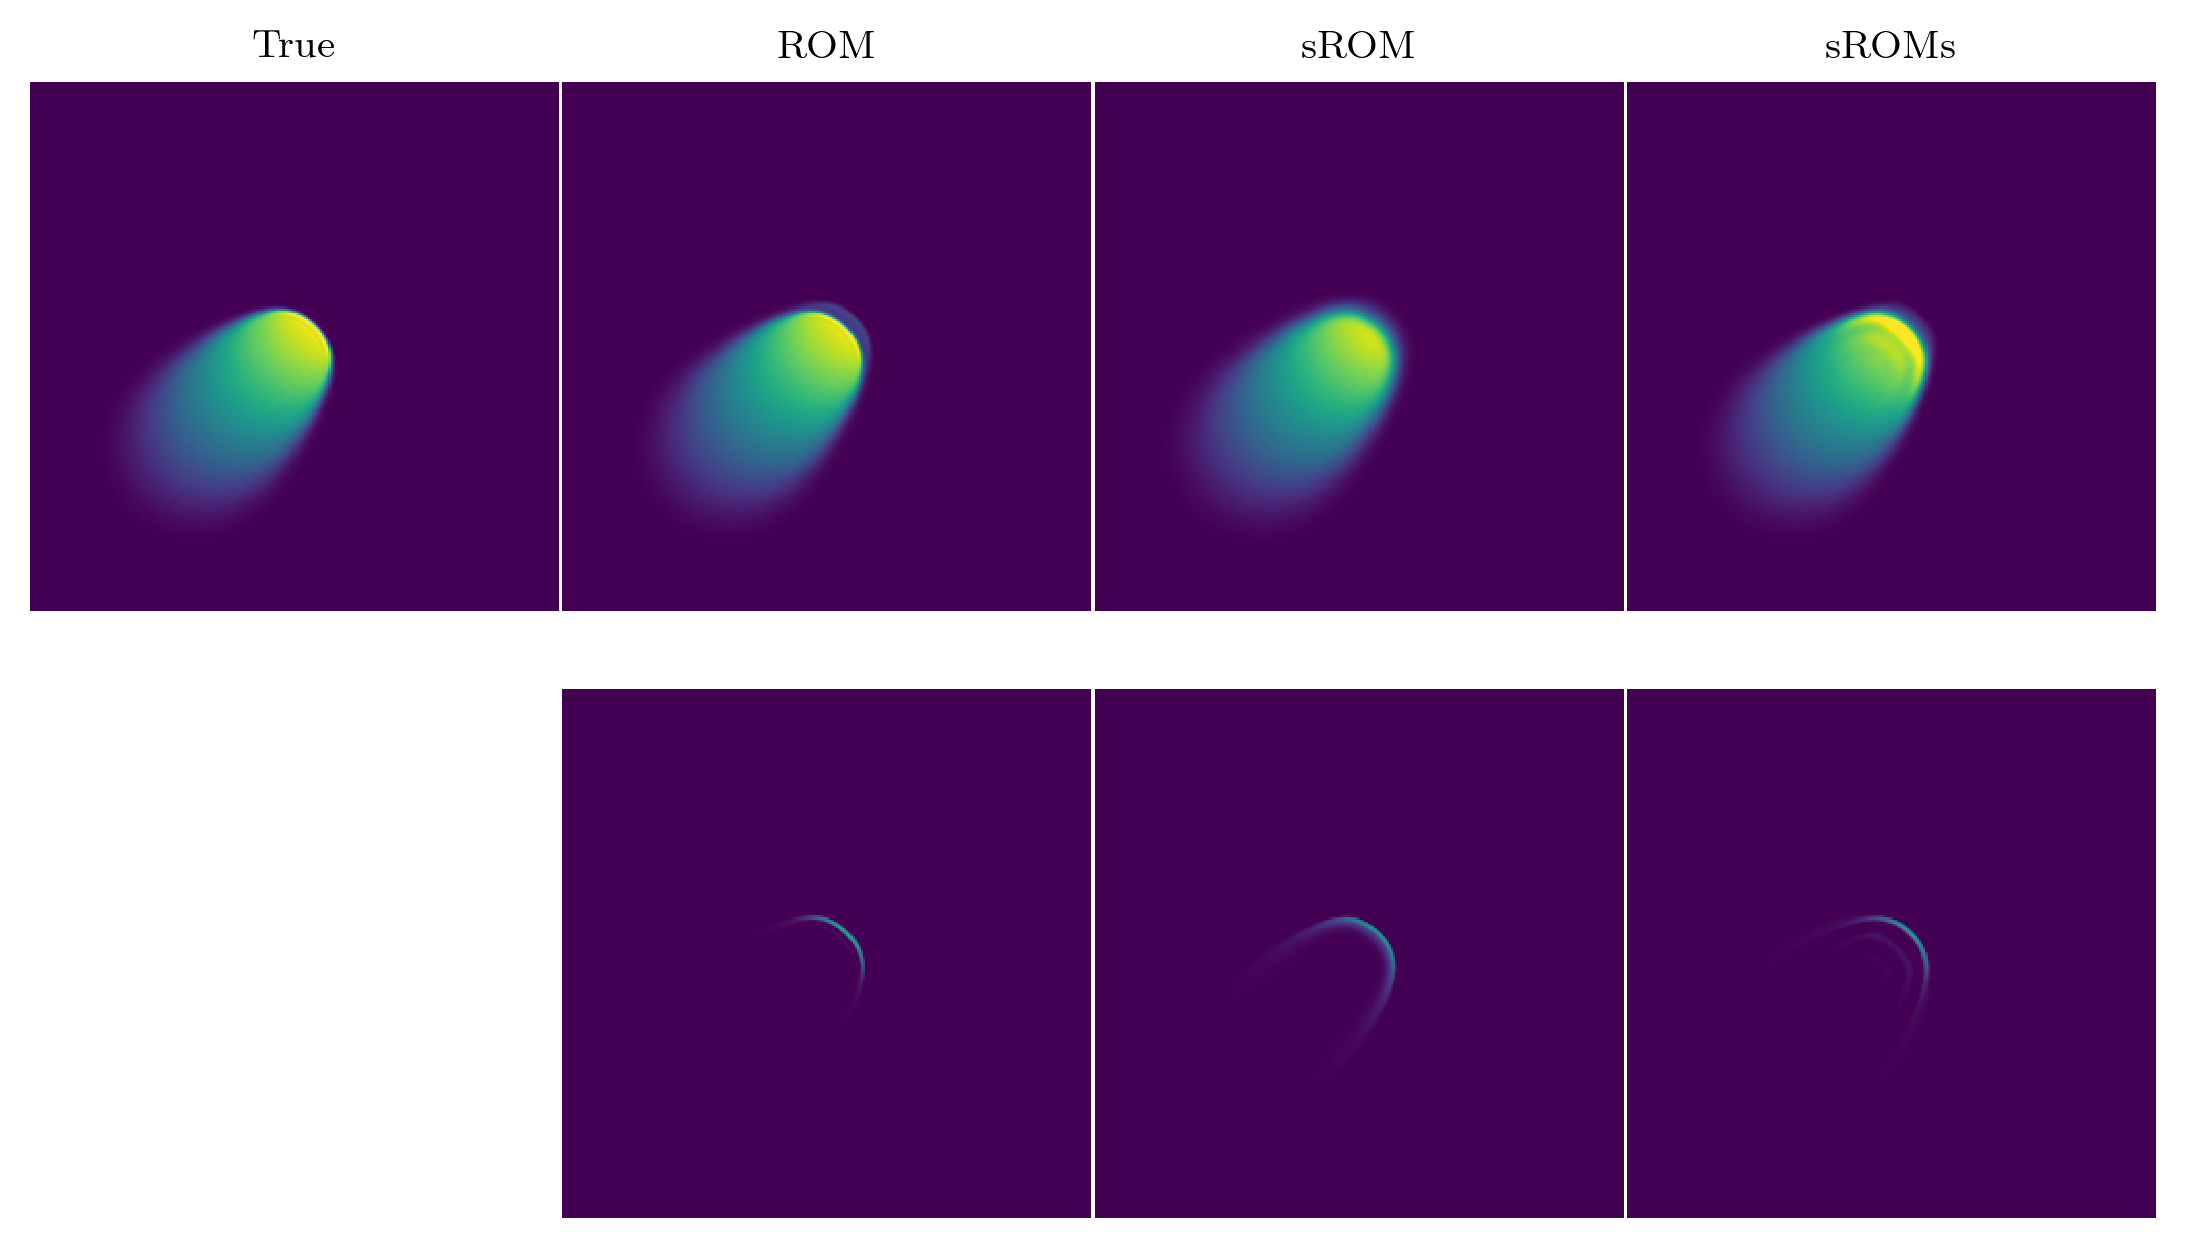

18 [0.654] 0.0036831828104846817 0.013712685753489343 0.006909925121987157 87.60744382052158


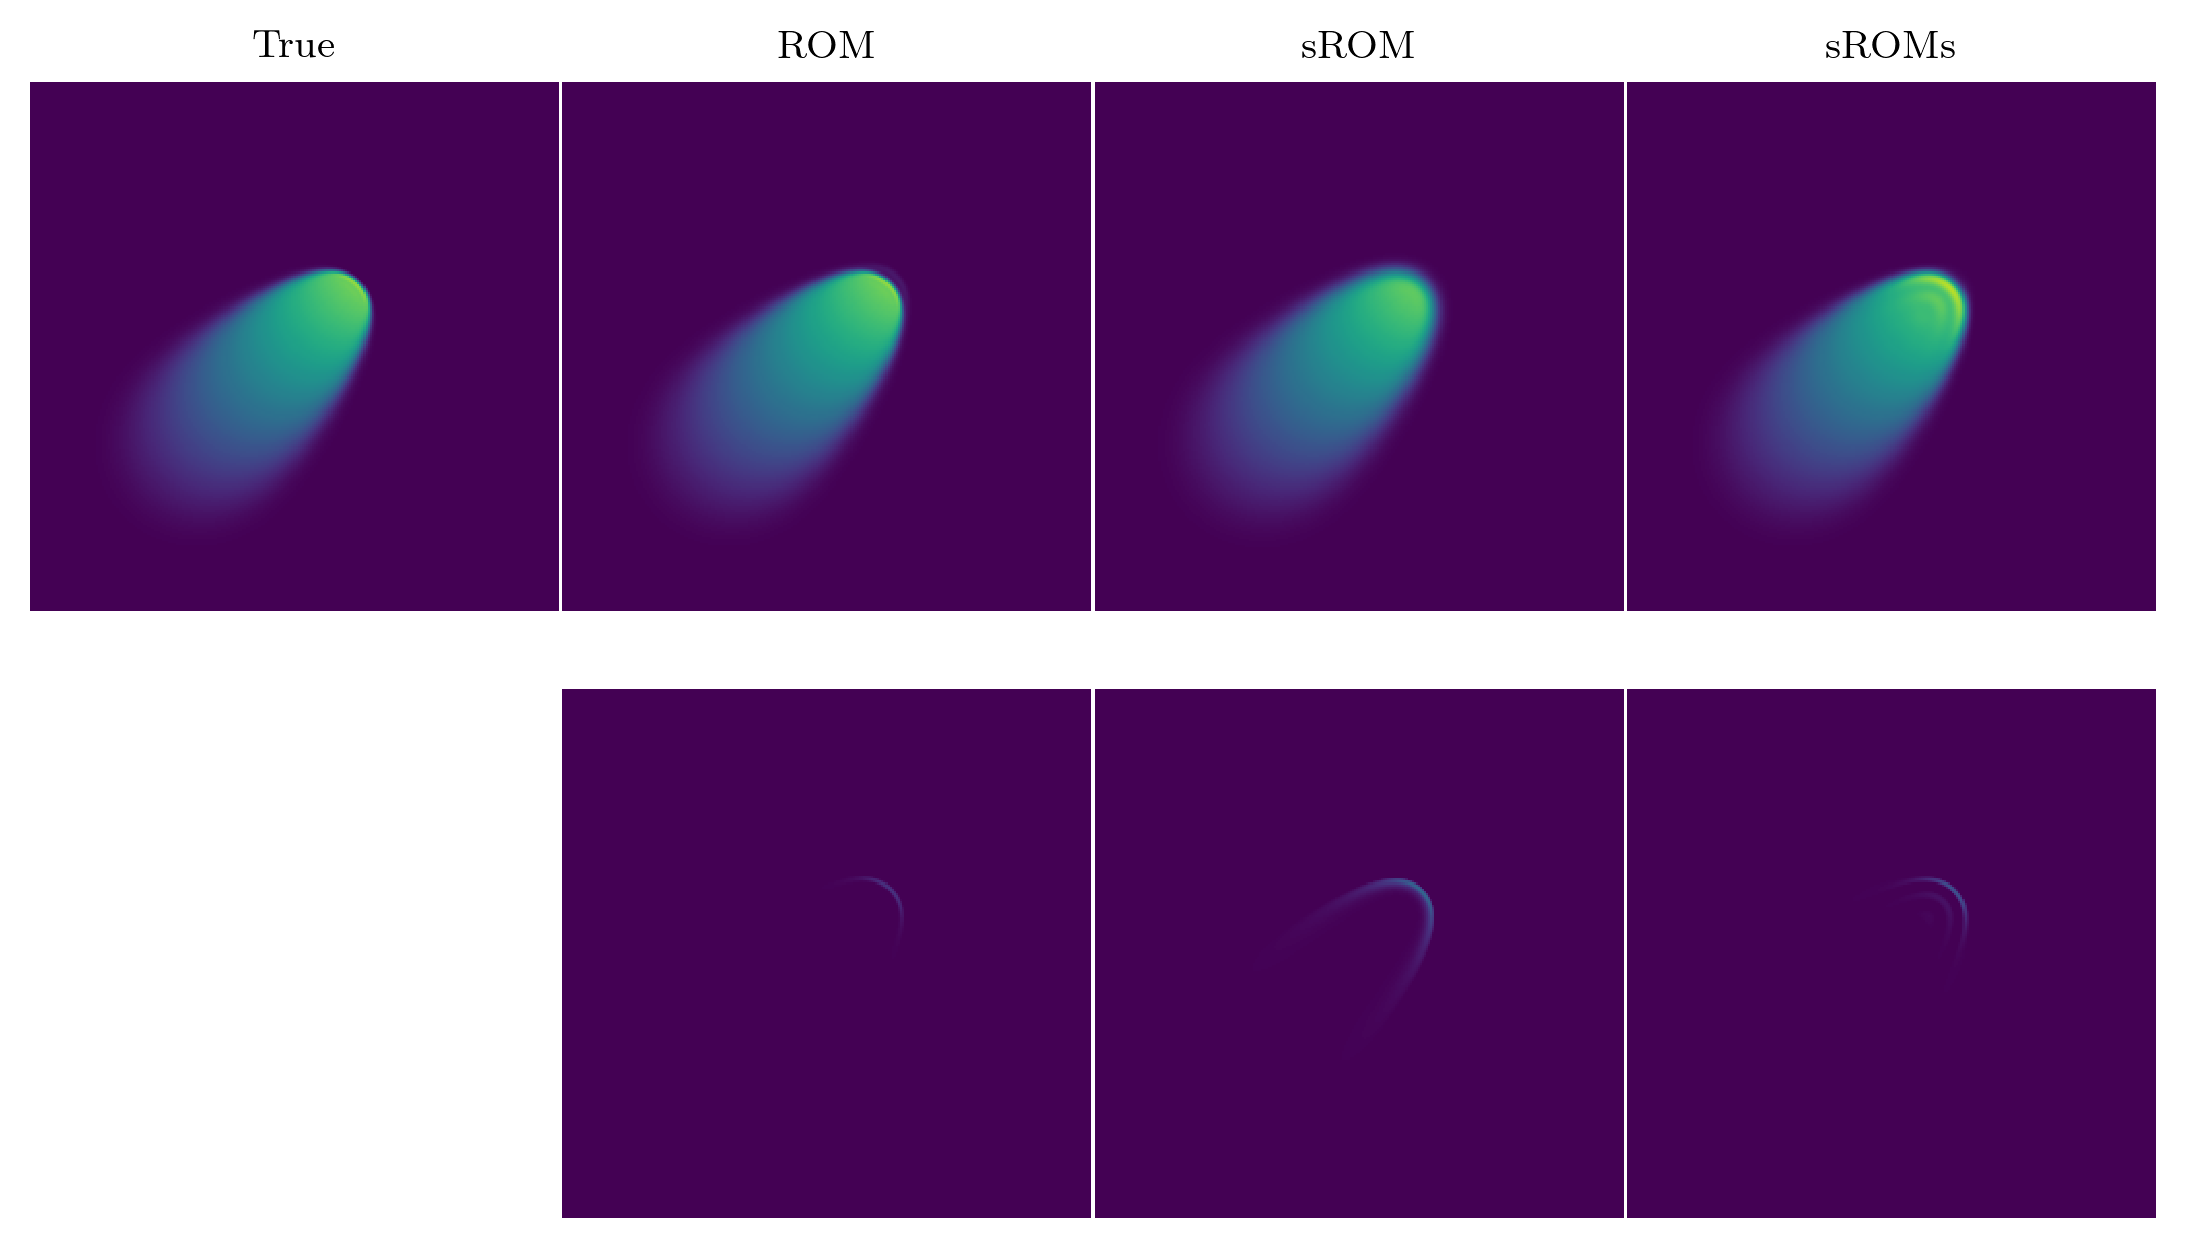

19 [0.495] 0.007441625642462148 0.017646832142233594 0.005609260184621571 -24.623187807043706


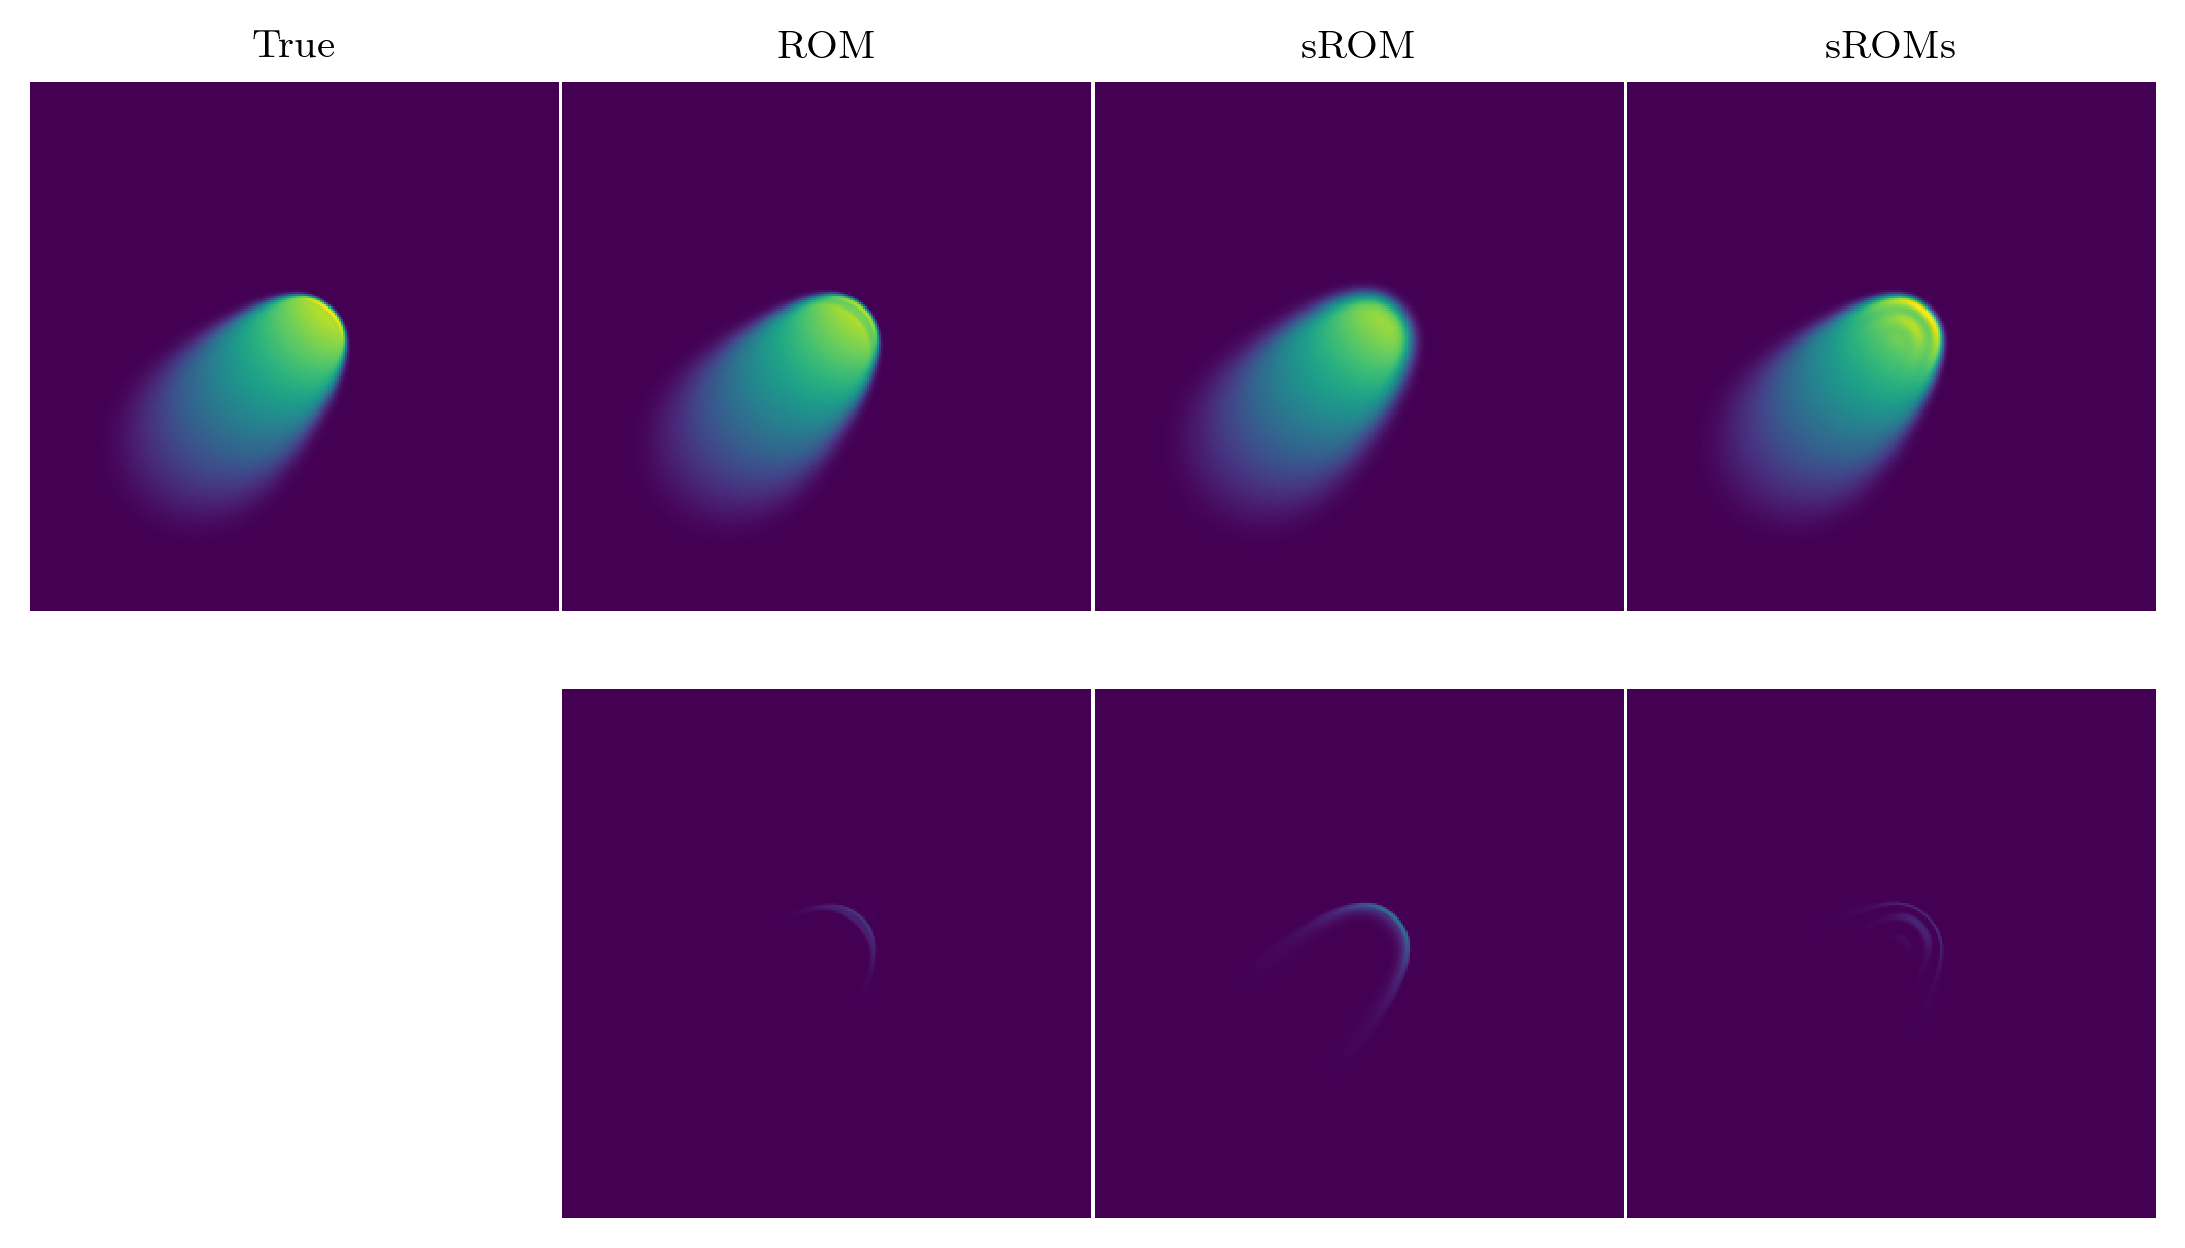

In [8]:
X_grid = np.asarray(x)
Y_grid = np.asarray(y)
X_mesh, Y_mesh = np.meshgrid(X_grid, Y_grid, indexing="ij")
mean_train = np.mean(X_train, axis=0).reshape(shape)

for i in range(len(X_test_ROM)):
    print(i, mu_test[i], e_ROM[i], e_sROM[i], e_sROMs[i], 100 * e_sROMs[i] / e_ROM[i] - 100)
    fig, axs = plt.subplots(2, 4,  figsize=(single_column_in*2, single_column_in*2/1.618))
    for col, (Z, title) in enumerate([
        (X_test[i], "True"),
        (X_test_ROM[i], "ROM"),
        (X_test_sROM[i], "sROM"),
        (X_test_sROMs[i], "sROMs"),
    ]):
        ax = axs[0, col]
        ax.pcolormesh(X_mesh, Y_mesh, Z.reshape(shape), vmin=0, vmax=1)
        ax.set_aspect("equal")
        ax.set_title(title)
        ax.set_axis_off()
        
        ax = axs[1, col]
        ax.set_aspect("equal")
        ax.set_axis_off()
        if col != 0:
            ax.pcolormesh(X_mesh, Y_mesh, (X_test[i]-Z).reshape(shape), vmin=0, vmax=1)
    plt.tight_layout(pad=0.0, w_pad=0.1, h_pad=0.1)
    pth = "../Plots/Burgers2D_ss"+str(i)
    plt.savefig(pth+"_results.pdf")
    plt.show()

In [ ]:
jj = int(np.ceil(len(mu_val_all)/20))

In [ ]:
jj